# Telco Customer Churn — Model Training

This notebook focuses on training machine learning models to predict customer churn using the cleaned Telco Customer Churn dataset.

The objective is to build reproducible training pipelines and compare different classification algorithms.

## Modeling Goals

The model training stage focuses on:

- Preparing features for machine learning models
- Building preprocessing pipelines
- Preventing data leakage
- Performing cross-validation
- Exploring hyperparameter tuning
- Comparing multiple classification models
- Creating reproducible training workflows

## Models Used

The following machine learning models are explored:

- **Logistic Regression**
- **Decision Tree Classifier**
- **Random Forest Classifier**
- **XGBoost Classifier**


## Import Section

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from joblib import Memory, dump, load
from scipy.stats import loguniform, uniform
from sklearn.compose import (
	ColumnTransformer,
	make_column_selector,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
	ConfusionMatrixDisplay,
	RocCurveDisplay,
	accuracy_score,
	average_precision_score,
	classification_report,
	confusion_matrix,
	f1_score,
	precision_score,
	recall_score,
	roc_auc_score,
)
from sklearn.model_selection import (
	RandomizedSearchCV,
	RepeatedStratifiedKFold,
	cross_val_score,
	train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

/workspace/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Processed Dataset

The dataset used in this notebook was previously cleaned and standardized during the data preparation stage.

In [2]:
telco_churn = pd.read_parquet('data/processed/telco_churn_clean.parquet')

In [3]:
telco_churn.sample(5)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
4544,Male,0,Yes,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.550003,Yes
3680,Male,0,Yes,No,9,No,No phone service,DSL,No,No,No,Yes,Yes,No,Month-to-month,No,Mailed check,40.650002,Yes
1701,Female,0,Yes,Yes,66,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),102.449997,Yes
4450,Male,0,No,No,15,Yes,Yes,DSL,No,Yes,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),58.599998,Yes
6226,Male,0,No,No,65,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.750000,No


## Reproducibility Configuration

A fixed random state is defined to ensure reproducible experiments across all training procedures.

In [4]:
RANDOM_STATE = 42

## Feature and Target Definition

The dataset is separated into:

- Features (X)
- Target variable (y)

Customer churn is used as the prediction target.

In [5]:
X = telco_churn.drop('Churn', axis=1)
y = telco_churn['Churn']

In [6]:
X.shape, y.shape

((7043, 18), (7043,))

## Train-Test Split

The dataset is divided into training and testing subsets.

Stratification is applied to preserve the original churn distribution.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	stratify=y,
	random_state=RANDOM_STATE,
)

In [8]:
X_train.shape, y_train.shape

((5634, 18), (5634,))

In [9]:
X_train.dtypes

Gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
Tenure                 int16
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float32
dtype: object

In [10]:
y_train.dtypes

CategoricalDtype(categories=['No', 'Yes'], ordered=False, categories_dtype=str)

In [11]:
X_test.shape, y_test.shape

((1409, 18), (1409,))

## Feature Preprocessing

Different preprocessing strategies are applied depending on feature type:

- Numerical features are standardized using scaling transformations
- Categorical features are encoded using one-hot encoding

Separate preprocessing pipelines are combined using a ColumnTransformer to centralize transformations and ensure reproducible workflows.

In [12]:
num_pipe = Pipeline(
	steps=[
		('scl', StandardScaler()),
	]
)

In [13]:
display(num_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scl', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
cat_pipe = Pipeline(
	steps=[
		('enc', OneHotEncoder(handle_unknown='ignore')),
	]
)

In [15]:
display(cat_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('enc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies 

In [16]:
num_cols = make_column_selector(dtype_include=np.number)
cat_cols = make_column_selector(dtype_include='category')

In [17]:
prep = ColumnTransformer(
	transformers=[
		('num', num_pipe, num_cols),
		('cat', cat_pipe, cat_cols),
	],
)

In [18]:
display(prep)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Cross-Validation Strategy

Repeated Stratified K-Fold cross-validation is used to preserve class proportions across validation folds while improving robustness through multiple repetitions.

This strategy reduces variance in performance estimation and provides more stable evaluation results for imbalanced classification tasks.

In [19]:
RSKF_N_SPLITS = 5
RSKF_N_REPEATS = 5

In [20]:
rskf = RepeatedStratifiedKFold(
	n_splits=RSKF_N_SPLITS,
	n_repeats=RSKF_N_REPEATS,
	random_state=RANDOM_STATE,
)

## Helper Functions

Reusable utilities for model evaluation and artifact persistence.

Centralizing these routines eliminates repeated boilerplate across model sections and guarantees consistent evaluation logic for every classifier.

In [21]:
def compute_metrics(y_test, y_pred, y_proba, pos_label='Yes'):
	"""
	Compute all classification metrics for churn prediction.

	Returns
	-------
	dict
	    ROC-AUC, accuracy, precision, recall, and F1 on the test set.
	"""
	return {
		'test_roc_auc': roc_auc_score(y_test, y_proba),
		'test_pr_auc': average_precision_score(
			y_test,
			y_proba,
			pos_label=pos_label,
		),
		'test_accuracy': accuracy_score(y_test, y_pred),
		'test_precision': precision_score(
			y_test,
			y_pred,
			pos_label=pos_label,
		),
		'test_recall': recall_score(
			y_test,
			y_pred,
			pos_label=pos_label,
		),
		'test_f1': f1_score(
			y_test,
			y_pred,
			pos_label=pos_label,
		),
	}


def print_metrics(metrics):
	"""Print classification metrics in a formatted layout."""
	print(f'ROC-AUC  : {metrics["test_roc_auc"]:.4f}')
	print(f'PR-AUC   : {metrics["test_pr_auc"]:.4f}')
	print(f'Accuracy : {metrics["test_accuracy"]:.4f}')
	print(f'Precision: {metrics["test_precision"]:.4f}')
	print(f'Recall   : {metrics["test_recall"]:.4f}')
	print(f'F1-Score : {metrics["test_f1"]:.4f}')


def build_classification_report(y_test, y_pred):
	"""
	Return a tidy DataFrame classification report,
	excluding the accuracy row.
	"""
	report = classification_report(
		y_test,
		y_pred,
		output_dict=True,
	)

	return pd.DataFrame(report).transpose().iloc[:-1, :]


def plot_confusion_matrix(pipe, y_test, y_pred, title):
	"""Display a styled confusion matrix for a trained pipeline."""
	labels = pipe.classes_

	cm = confusion_matrix(
		y_test,
		y_pred,
		labels=labels,
	)

	disp = ConfusionMatrixDisplay(
		confusion_matrix=cm,
		display_labels=labels,
	)

	_, ax = plt.subplots(figsize=(6, 5))

	disp.plot(
		cmap='viridis',
		ax=ax,
	)

	ax.set_title(title, pad=12)

	plt.show()


def plot_roc_curve(pipe, X_test, y_test, title):
	"""Display a styled ROC curve for a trained pipeline."""
	_, ax = plt.subplots(figsize=(6, 5))

	ax.set_title(title, pad=12)

	RocCurveDisplay.from_estimator(
		pipe,
		X_test,
		y_test,
		ax=ax,
	)


def save_artifacts(base_path, artifacts_dict, best_pipe):
	"""
	Export trained pipeline and training metadata to disk.

	Saves two files under *base_path*:
	  - {model_name}_artifacts.joblib
	  - {model_name}_best_model.joblib
	"""
	model_name = artifacts_dict['model_name']

	os.makedirs(base_path, exist_ok=True)

	dump(
		artifacts_dict,
		filename=f'{base_path}/{model_name}_artifacts.joblib',
	)

	dump(
		best_pipe,
		filename=f'{base_path}/{model_name}_best_model.joblib',
	)

# Logistic Regression

## Pipeline Definition

A machine learning pipeline is created to combine:

- Feature preprocessing
- Logistic Regression training

This structure prevents leakage and guarantees reproducible workflows.

In [22]:
# Logistic Regression is configured with balanced class weights
# to compensate for the moderate imbalance between churned and
# retained customers.
logreg_clf = LogisticRegression(
	class_weight='balanced',
	random_state=RANDOM_STATE,
	max_iter=5000,
)

In [23]:
memory = Memory(location='cache', verbose=0)

In [24]:
logreg_pipe = Pipeline(
	steps=[
		('prep', prep),
		('clf', logreg_clf),
	],
	memory=memory,
)

In [25]:
display(logreg_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(location=cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

## Hyperparameter Search Space

A randomized hyperparameter search is configured to explore different Logistic Regression configurations.

In [26]:
logreg_param_dist = [
	{
		'clf__solver': ['lbfgs', 'newton-cholesky'],
		'clf__l1_ratio': [0.0],
		'clf__C': loguniform(1e-6, 1e6),
	},
	{
		'clf__solver': ['saga'],
		'clf__l1_ratio': uniform(0, 1),
		'clf__C': loguniform(1e-6, 1e6),
	},
]

## Randomized Search Configuration

RandomizedSearchCV is used to:

- Train multiple parameter combinations
- Perform cross-validation
- Compare model configurations
- Select the best-performing estimator

In [27]:
logreg_search = RandomizedSearchCV(
	estimator=logreg_pipe,
	param_distributions=logreg_param_dist,
	n_iter=100,
	scoring='roc_auc',
	n_jobs=-1,
	cv=rskf,
	random_state=RANDOM_STATE,
)

In [28]:
logreg_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(memo...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'clf__C': <scipy.stats....x7f1790604590>, 'clf__l1_ratio': [0.0], 'clf__solver': ['lbfgs', 'newton-cholesky']}, {'clf__C': <scipy.stats....x7f17e09896d0>, 'clf__l1_ratio': <scipy.stats....x7f17e0989450>, 'clf__solver': ['saga']}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same ac

## Best Hyperparameters

The randomized search identified the best Logistic Regression configuration based on ROC-AUC performance during cross-validation.

The selected parameters represent the configuration that achieved the best balance between model generalization and predictive performance.

In [29]:
display(logreg_search.best_params_)

{'clf__C': np.float64(0.24048595405991793),
 'clf__l1_ratio': np.float64(0.9944574626108207),
 'clf__solver': 'saga'}

## Cross-Validation Performance

The best cross-validation ROC-AUC score obtained during hyperparameter search is analyzed below.

ROC-AUC is particularly useful for churn prediction because it evaluates the model's ability to distinguish churned customers from retained customers across different classification thresholds.

In [30]:
display(logreg_search.best_score_)

np.float64(0.8447343291151279)

## Best Estimator

In [31]:
best_logreg_clf = logreg_search.best_estimator_

In [32]:
display(best_logreg_clf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(location=cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

## Test Set Inference

After selecting the best estimator through cross-validation, the optimized pipeline is applied to the unseen test set.

This step simulates real-world inference by evaluating the model on data that was not used during training or hyperparameter optimization.

Both class predictions and predicted probabilities are generated for downstream performance evaluation.

In [33]:
y_pred_logreg = best_logreg_clf.predict(X_test)

logreg_start = time.time()

y_proba_logreg = best_logreg_clf.predict_proba(X_test)[:, 1]

logreg_predict_time = time.time() - logreg_start

## Model Evaluation Metrics

The trained Logistic Regression model is evaluated using multiple classification metrics on the test set.

Since customer churn prediction is a moderately imbalanced classification task, multiple metrics are analyzed for a complete assessment:

- ROC-AUC Score
- PR AUC Score
- Accuracy
- Precision
- Recall
- F1-Score

These metrics help assess the model's ability to correctly identify churned customers while balancing false positives and false negatives.

In [34]:
logreg_metrics = compute_metrics(y_test, y_pred_logreg, y_proba_logreg)

print_metrics(logreg_metrics)

ROC-AUC  : 0.8395
PR-AUC   : 0.6310
Accuracy : 0.7402
Precision: 0.5070
Recall   : 0.7781
F1-Score : 0.6139


### Classification Report

A detailed classification report summarizes model performance across both churn classes.

In [35]:
display(build_classification_report(y_test, y_pred_logreg))

,precision,recall,f1-score,support
No,0.900599,0.726570,0.804278,1035.000000
Yes,0.506969,0.778075,0.613924,374.000000
accuracy,0.740241,0.740241,0.740241,0.740241
macro avg,0.703784,0.752322,0.709101,1409.000000


### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of prediction outcomes, including correctly and incorrectly classified samples.

This visualization helps analyze the trade-off between false positives and false negatives, which is particularly important in churn prediction tasks.

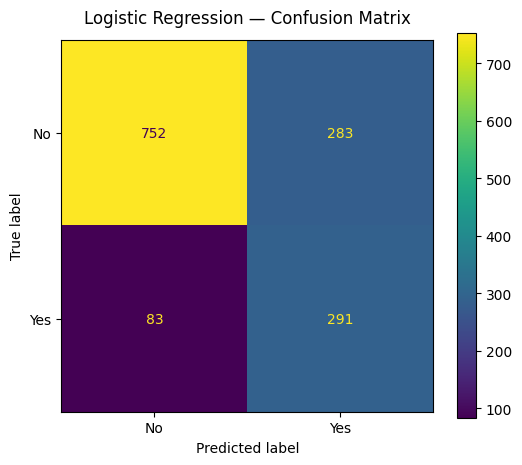

In [36]:
plot_confusion_matrix(
	best_logreg_clf,
	y_test,
	y_pred_logreg,
	'Logistic Regression — Confusion Matrix',
)

### ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve illustrates the model's ability to separate churned and retained customers across multiple classification thresholds.

The closer the curve approaches the top-left corner, the better the discriminative performance.

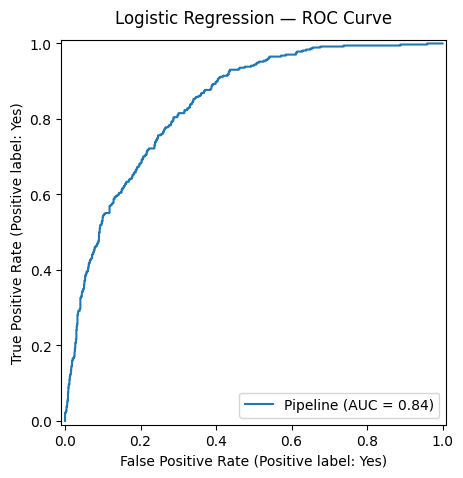

In [37]:
plot_roc_curve(
	best_logreg_clf,
	X_test,
	y_test,
	'Logistic Regression — ROC Curve',
)

## Model Export and Saved Artifacts

The best trained pipeline and training metadata are exported for downstream evaluation and deployment workflows.

The following artifacts are persisted:

- Best trained Logistic Regression pipeline
- Best hyperparameter configuration
- Best cross-validation ROC-AUC score

The exported pipeline includes both preprocessing and model steps, ensuring reproducible transformations during future inference.

In [38]:
base_logreg_path = 'models/logistic_regression'

logreg_artifacts = {
	'model_name': 'logistic_regression',
	'best_params': logreg_search.best_params_,
	'best_cv_score': logreg_search.best_score_,
	'best_index': logreg_search.best_index_,
	'test_metrics': logreg_metrics,
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
	'predict_time': logreg_predict_time,
}

save_artifacts(base_logreg_path, logreg_artifacts, best_logreg_clf)

# Decision Tree

This section trains an optimized Decision Tree classifier using **Optuna** for hyperparameter search.

Unlike Logistic Regression, which uses `RandomizedSearchCV` with a predefined parameter distribution, the Decision Tree leverages Optuna's Bayesian optimization to efficiently navigate a wider search space.

Numeric features are passed through without scaling since Decision Trees are invariant to feature magnitude.

## Pipeline Definition

The Decision Tree pipeline differs from the Logistic Regression pipeline in one important way: numerical features are passed through **without scaling**.

Decision Trees partition the feature space by thresholds, so the absolute scale of a feature does not affect the result. Applying `StandardScaler` would add unnecessary computation with no benefit.

The pipeline is rebuilt inside the Optuna objective on each trial to avoid state leakage when `memory` caching is active.

## Optuna Objective Function

The objective function defines the **search space** and **evaluation strategy** for each trial.

For each trial, Optuna suggests a combination of hyperparameters. A full pipeline, preprocessor + classifier, is assembled and evaluated using the shared `RepeatedStratifiedKFold` cross-validation strategy.

The mean ROC-AUC across all folds is returned as the objective value to maximize.

In [39]:
def objective(trial):
	criterion = trial.suggest_categorical(
		'criterion',
		['gini', 'entropy', 'log_loss'],
	)

	max_depth = trial.suggest_int(
		'max_depth',
		3,
		30,
	)

	min_samples_leaf = trial.suggest_int(
		'min_samples_leaf',
		5,
		100,
	)

	min_samples_split = trial.suggest_int(
		'min_samples_split',
		10,
		100,
	)

	max_features = trial.suggest_float(
		'max_features',
		0.2,
		1.0,
	)

	dt_clf = DecisionTreeClassifier(
		criterion=criterion,
		max_depth=max_depth,
		min_samples_split=min_samples_split,
		min_samples_leaf=min_samples_leaf,
		max_features=max_features,
		random_state=RANDOM_STATE,
		class_weight='balanced',
	)

	dt_prep = ColumnTransformer(
		transformers=[
			('num', 'passthrough', num_cols),
			('cat', cat_pipe, cat_cols),
		],
	)

	dt_pipe = Pipeline(
		steps=[
			('prep', dt_prep),
			('clf', dt_clf),
		],
		memory=memory,
	)

	scores = cross_val_score(
		dt_pipe,
		X_train,
		y_train,
		scoring='roc_auc',
		cv=rskf,
		n_jobs=1,
	)

	mean_roc_auc = scores.mean()

	return mean_roc_auc

## Optuna Study Configuration

A new Optuna study is created with `direction='maximize'` to find the hyperparameter configuration that yields the highest mean cross-validation ROC-AUC.

Setting `gc_after_trial=True` releases trial memory between runs, which prevents accumulation when fitting many pipelines.

In [40]:
dt_study = optuna.create_study(direction='maximize')

[I 2026-05-25 21:44:00,424] A new study created in memory with name: no-name-a2bfc039-036b-4d08-9a6f-4d9eada43ae8


In [41]:
dt_study.optimize(
	objective,
	n_trials=100,
	n_jobs=-1,
	gc_after_trial=True,
	show_progress_bar=True,
)

Best trial: 6. Best value: 0.824989:   1%|          | 1/100 [00:26<42:57, 26.03s/it]

[I 2026-05-25 21:44:26,294] Trial 6 finished with value: 0.8249888278931121 and parameters: {'criterion': 'entropy', 'max_depth': 23, 'min_samples_leaf': 30, 'min_samples_split': 48, 'max_features': 0.7186812368848732}. Best is trial 6 with value: 0.8249888278931121.
[I 2026-05-25 21:44:26,444] Trial 1 finished with value: 0.8265147425215702 and parameters: {'criterion': 'log_loss', 'max_depth': 14, 'min_samples_leaf': 50, 'min_samples_split': 20, 'max_features': 0.33736436662379693}. Best is trial 1 with value: 0.8265147425215702.


Best trial: 2. Best value: 0.833061:   2%|▏         | 2/100 [00:26<17:48, 10.91s/it] 

[I 2026-05-25 21:44:26,453] Trial 11 finished with value: 0.8312720646668937 and parameters: {'criterion': 'gini', 'max_depth': 18, 'min_samples_leaf': 44, 'min_samples_split': 68, 'max_features': 0.866978451942797}. Best is trial 11 with value: 0.8312720646668937.
[I 2026-05-25 21:44:26,608] Trial 5 finished with value: 0.8167952290248699 and parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 84, 'min_samples_split': 48, 'max_features': 0.2450004504019968}. Best is trial 11 with value: 0.8312720646668937.


Best trial: 10. Best value: 0.833435:   5%|▌         | 5/100 [00:26<03:21,  2.12s/it]

[I 2026-05-25 21:44:26,616] Trial 21 finished with value: 0.8267355696615004 and parameters: {'criterion': 'entropy', 'max_depth': 29, 'min_samples_leaf': 73, 'min_samples_split': 75, 'max_features': 0.39544361680268064}. Best is trial 11 with value: 0.8312720646668937.
[I 2026-05-25 21:44:26,624] Trial 4 finished with value: 0.8202038943207971 and parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 92, 'min_samples_split': 30, 'max_features': 0.27987599771896443}. Best is trial 11 with value: 0.8312720646668937.


Best trial: 10. Best value: 0.833435:   6%|▌         | 6/100 [00:26<03:19,  2.12s/it]

[I 2026-05-25 21:44:26,629] Trial 16 finished with value: 0.8281753649973331 and parameters: {'criterion': 'log_loss', 'max_depth': 4, 'min_samples_leaf': 27, 'min_samples_split': 62, 'max_features': 0.9668706297243517}. Best is trial 11 with value: 0.8312720646668937.
[I 2026-05-25 21:44:26,659] Trial 15 finished with value: 0.8171851689631465 and parameters: {'criterion': 'gini', 'max_depth': 19, 'min_samples_leaf': 6, 'min_samples_split': 69, 'max_features': 0.319353072832749}. Best is trial 11 with value: 0.8312720646668937.


Best trial: 10. Best value: 0.833435:   9%|▉         | 9/100 [00:27<00:50,  1.79it/s]

[I 2026-05-25 21:44:26,671] Trial 8 finished with value: 0.821703717581329 and parameters: {'criterion': 'gini', 'max_depth': 21, 'min_samples_leaf': 10, 'min_samples_split': 79, 'max_features': 0.44103340754215686}. Best is trial 11 with value: 0.8312720646668937.
[I 2026-05-25 21:44:26,779] Trial 9 finished with value: 0.830254682228336 and parameters: {'criterion': 'gini', 'max_depth': 21, 'min_samples_leaf': 62, 'min_samples_split': 65, 'max_features': 0.5105945497399655}. Best is trial 11 with value: 0.8312720646668937.


Best trial: 10. Best value: 0.833435:  11%|█         | 11/100 [00:27<00:33,  2.66it/s]

[I 2026-05-25 21:44:26,780] Trial 23 finished with value: 0.8293297616976024 and parameters: {'criterion': 'log_loss', 'max_depth': 15, 'min_samples_leaf': 97, 'min_samples_split': 35, 'max_features': 0.3935066365352146}. Best is trial 11 with value: 0.8312720646668937.
[I 2026-05-25 21:44:26,782] Trial 3 finished with value: 0.8286477841356317 and parameters: {'criterion': 'entropy', 'max_depth': 24, 'min_samples_leaf': 27, 'min_samples_split': 99, 'max_features': 0.9602748850803633}. Best is trial 11 with value: 0.8312720646668937.


Best trial: 10. Best value: 0.833435:  13%|█▎        | 13/100 [00:27<00:23,  3.72it/s]

[I 2026-05-25 21:44:26,788] Trial 2 finished with value: 0.8330606148486044 and parameters: {'criterion': 'entropy', 'max_depth': 23, 'min_samples_leaf': 57, 'min_samples_split': 66, 'max_features': 0.9677220266079936}. Best is trial 2 with value: 0.8330606148486044.
[I 2026-05-25 21:44:26,799] Trial 13 finished with value: 0.8235810230555285 and parameters: {'criterion': 'log_loss', 'max_depth': 23, 'min_samples_leaf': 12, 'min_samples_split': 96, 'max_features': 0.45038548858218797}. Best is trial 2 with value: 0.8330606148486044.


Best trial: 10. Best value: 0.833435:  14%|█▍        | 14/100 [00:27<00:22,  3.87it/s]

[I 2026-05-25 21:44:26,801] Trial 18 finished with value: 0.8311470606398753 and parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 78, 'min_samples_split': 10, 'max_features': 0.6651139042508285}. Best is trial 2 with value: 0.8330606148486044.
[I 2026-05-25 21:44:26,919] Trial 22 finished with value: 0.8288705887882999 and parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 50, 'min_samples_split': 71, 'max_features': 0.47943307556493997}. Best is trial 2 with value: 0.8330606148486044.


Best trial: 10. Best value: 0.833435:  17%|█▋        | 17/100 [00:28<00:12,  6.54it/s]

[I 2026-05-25 21:44:26,943] Trial 17 finished with value: 0.8195152342036792 and parameters: {'criterion': 'entropy', 'max_depth': 29, 'min_samples_leaf': 21, 'min_samples_split': 66, 'max_features': 0.3137606903298342}. Best is trial 2 with value: 0.8330606148486044.
[I 2026-05-25 21:44:26,952] Trial 0 finished with value: 0.8189810521770506 and parameters: {'criterion': 'entropy', 'max_depth': 22, 'min_samples_leaf': 84, 'min_samples_split': 78, 'max_features': 0.31321778486597635}. Best is trial 2 with value: 0.8330606148486044.


Best trial: 10. Best value: 0.833435:  18%|█▊        | 18/100 [00:28<00:12,  6.49it/s]

[I 2026-05-25 21:44:26,954] Trial 7 finished with value: 0.8251099437104379 and parameters: {'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 51, 'min_samples_split': 77, 'max_features': 0.33089625504418796}. Best is trial 2 with value: 0.8330606148486044.
[I 2026-05-25 21:44:27,050] Trial 10 finished with value: 0.8334350468827009 and parameters: {'criterion': 'entropy', 'max_depth': 29, 'min_samples_leaf': 74, 'min_samples_split': 65, 'max_features': 0.9020339872760954}. Best is trial 10 with value: 0.8334350468827009.


Best trial: 10. Best value: 0.833435:  21%|██        | 21/100 [00:28<00:13,  6.05it/s]

[I 2026-05-25 21:44:27,063] Trial 20 finished with value: 0.8304998855047085 and parameters: {'criterion': 'gini', 'max_depth': 25, 'min_samples_leaf': 48, 'min_samples_split': 72, 'max_features': 0.592513609335784}. Best is trial 10 with value: 0.8334350468827009.
[I 2026-05-25 21:44:27,074] Trial 12 finished with value: 0.8247183321076935 and parameters: {'criterion': 'log_loss', 'max_depth': 21, 'min_samples_leaf': 89, 'min_samples_split': 80, 'max_features': 0.4447304292206024}. Best is trial 10 with value: 0.8334350468827009.


Best trial: 10. Best value: 0.833435:  23%|██▎       | 23/100 [00:29<00:13,  5.65it/s]

[I 2026-05-25 21:44:27,075] Trial 19 finished with value: 0.8203199097689969 and parameters: {'criterion': 'log_loss', 'max_depth': 6, 'min_samples_leaf': 35, 'min_samples_split': 89, 'max_features': 0.25957922481705253}. Best is trial 10 with value: 0.8334350468827009.
[I 2026-05-25 21:44:27,078] Trial 14 finished with value: 0.8314196121828304 and parameters: {'criterion': 'entropy', 'max_depth': 13, 'min_samples_leaf': 100, 'min_samples_split': 31, 'max_features': 0.6020137234208339}. Best is trial 10 with value: 0.8334350468827009.


Best trial: 10. Best value: 0.833435:  25%|██▌       | 25/100 [00:40<03:58,  3.18s/it]

[I 2026-05-25 21:44:40,436] Trial 25 finished with value: 0.8288196142068407 and parameters: {'criterion': 'entropy', 'max_depth': 28, 'min_samples_leaf': 39, 'min_samples_split': 88, 'max_features': 0.846802925128394}. Best is trial 10 with value: 0.8334350468827009.
[I 2026-05-25 21:44:40,442] Trial 24 finished with value: 0.8286593509831328 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 96, 'min_samples_split': 85, 'max_features': 0.4131655734917976}. Best is trial 10 with value: 0.8334350468827009.


[I 2026-05-25 21:44:40,659] Trial 27 finished with value: 0.8323209822013891 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 65, 'min_samples_split': 53, 'max_features': 0.8180354523473924}. Best is trial 10 with value: 0.8334350468827009.
[I 2026-05-25 21:44:40,984] Trial 26 finished with value: 0.8285131050073916 and parameters: {'criterion': 'gini', 'max_depth': 26, 'min_samples_leaf': 39, 'min_samples_split': 53, 'max_features': 0.8505150382644071}. Best is trial 10 with value: 0.8334350468827009.


Best trial: 10. Best value: 0.833435:  28%|██▊       | 28/100 [00:40<01:37,  1.36s/it]

[I 2026-05-25 21:44:41,221] Trial 28 finished with value: 0.8325986819785779 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 63, 'min_samples_split': 55, 'max_features': 0.8118823021399212}. Best is trial 10 with value: 0.8334350468827009.
[I 2026-05-25 21:44:41,227] Trial 32 finished with value: 0.8331460912835276 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 63, 'min_samples_split': 55, 'max_features': 0.8420261747452766}. Best is trial 10 with value: 0.8334350468827009.


Best trial: 33. Best value: 0.834296:  30%|███       | 30/100 [00:41<00:50,  1.37it/s]

[I 2026-05-25 21:44:41,512] Trial 33 finished with value: 0.8342957435747783 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 64, 'min_samples_split': 54, 'max_features': 0.8321451130708416}. Best is trial 33 with value: 0.8342957435747783.
[I 2026-05-25 21:44:41,515] Trial 29 finished with value: 0.8336200382956028 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 62, 'min_samples_split': 56, 'max_features': 0.8366260097755652}. Best is trial 33 with value: 0.8342957435747783.


Best trial: 30. Best value: 0.8344:  33%|███▎      | 33/100 [00:41<00:26,  2.54it/s]  

[I 2026-05-25 21:44:41,726] Trial 30 finished with value: 0.8343995814557758 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 65, 'min_samples_split': 56, 'max_features': 0.8403938457708433}. Best is trial 30 with value: 0.8343995814557758.
[I 2026-05-25 21:44:41,731] Trial 35 finished with value: 0.8343995814557758 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 65, 'min_samples_split': 54, 'max_features': 0.8238719863940448}. Best is trial 30 with value: 0.8343995814557758.


Best trial: 30. Best value: 0.8344:  35%|███▌      | 35/100 [00:41<00:20,  3.17it/s]

[I 2026-05-25 21:44:42,191] Trial 34 finished with value: 0.8342957435747783 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 64, 'min_samples_split': 52, 'max_features': 0.8242025992755031}. Best is trial 30 with value: 0.8343995814557758.
[I 2026-05-25 21:44:42,239] Trial 31 finished with value: 0.8323209822013891 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 65, 'min_samples_split': 57, 'max_features': 0.812691599242069}. Best is trial 30 with value: 0.8343995814557758.


[I 2026-05-25 21:44:42,337] Trial 37 finished with value: 0.8336920039735464 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 61, 'min_samples_split': 55, 'max_features': 0.8290776099924578}. Best is trial 30 with value: 0.8343995814557758.


Best trial: 30. Best value: 0.8344:  38%|███▊      | 38/100 [00:42<00:13,  4.58it/s]

[I 2026-05-25 21:44:42,697] Trial 38 finished with value: 0.832835180545526 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 63, 'min_samples_split': 53, 'max_features': 0.8265174432382648}. Best is trial 30 with value: 0.8343995814557758.
[I 2026-05-25 21:44:42,710] Trial 40 finished with value: 0.8336568720589699 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 66, 'min_samples_split': 50, 'max_features': 0.8328155869752969}. Best is trial 30 with value: 0.8343995814557758.


Best trial: 30. Best value: 0.8344:  40%|████      | 40/100 [00:42<00:12,  4.91it/s]

[I 2026-05-25 21:44:42,841] Trial 39 finished with value: 0.8342957435747783 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 64, 'min_samples_split': 55, 'max_features': 0.8307108949322022}. Best is trial 30 with value: 0.8343995814557758.
[I 2026-05-25 21:44:43,169] Trial 43 finished with value: 0.8329615714884627 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 66, 'min_samples_split': 53, 'max_features': 0.8119658687643927}. Best is trial 30 with value: 0.8343995814557758.


[I 2026-05-25 21:44:43,226] Trial 36 finished with value: 0.8346423975331612 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 60, 'min_samples_split': 55, 'max_features': 0.8338890545727593}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  42%|████▏     | 42/100 [00:43<00:10,  5.39it/s]

[I 2026-05-25 21:44:43,538] Trial 45 finished with value: 0.8336200382956028 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 62, 'min_samples_split': 57, 'max_features': 0.8285543390185529}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:43,565] Trial 41 finished with value: 0.8330335601221214 and parameters: {'criterion': 'entropy', 'max_depth': 28, 'min_samples_leaf': 65, 'min_samples_split': 54, 'max_features': 0.8517753959931458}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  45%|████▌     | 45/100 [00:43<00:11,  4.77it/s]

[I 2026-05-25 21:44:43,702] Trial 44 finished with value: 0.833743795485406 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 61, 'min_samples_split': 55, 'max_features': 0.7919204920183656}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:43,721] Trial 47 finished with value: 0.8342957435747783 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 64, 'min_samples_split': 55, 'max_features': 0.8267901751441432}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  46%|████▌     | 46/100 [00:43<00:12,  4.27it/s]

[I 2026-05-25 21:44:43,834] Trial 42 finished with value: 0.8336200382956028 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_leaf': 62, 'min_samples_split': 55, 'max_features': 0.8269009234389582}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  48%|████▊     | 48/100 [00:44<00:10,  5.02it/s]

[I 2026-05-25 21:44:44,504] Trial 46 finished with value: 0.8342957435747783 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 64, 'min_samples_split': 54, 'max_features': 0.8349690495995348}. Best is trial 36 with value: 0.8346423975331612.


[I 2026-05-25 21:44:54,944] Trial 50 finished with value: 0.8331939698716694 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 62, 'min_samples_split': 56, 'max_features': 0.8547152530520258}. Best is trial 36 with value: 0.8346423975331612.


[I 2026-05-25 21:44:55,144] Trial 49 finished with value: 0.8331939698716694 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 62, 'min_samples_split': 56, 'max_features': 0.844214779007132}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  51%|█████     | 51/100 [00:55<01:14,  1.51s/it]

[I 2026-05-25 21:44:55,365] Trial 51 finished with value: 0.833743795485406 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 61, 'min_samples_split': 58, 'max_features': 0.787079903173727}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:55,548] Trial 48 finished with value: 0.8331939698716694 and parameters: {'criterion': 'entropy', 'max_depth': 27, 'min_samples_leaf': 62, 'min_samples_split': 55, 'max_features': 0.8429274394796433}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  53%|█████▎    | 53/100 [00:55<00:41,  1.13it/s]

[I 2026-05-25 21:44:55,702] Trial 55 finished with value: 0.8335964017239177 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 70, 'min_samples_split': 40, 'max_features': 0.7565812882540148}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  54%|█████▍    | 54/100 [00:55<00:32,  1.40it/s]

[I 2026-05-25 21:44:56,020] Trial 52 finished with value: 0.833129912095632 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 71, 'min_samples_split': 41, 'max_features': 0.9118829798380925}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:56,206] Trial 56 finished with value: 0.831997981616321 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 57, 'min_samples_split': 41, 'max_features': 0.7671721289494327}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  56%|█████▌    | 56/100 [00:56<00:20,  2.12it/s]

[I 2026-05-25 21:44:56,280] Trial 57 finished with value: 0.8334609318445604 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 55, 'min_samples_split': 41, 'max_features': 0.7463471766893411}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:56,281] Trial 53 finished with value: 0.833619078746718 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 74, 'min_samples_split': 41, 'max_features': 0.7516112094996926}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  57%|█████▋    | 57/100 [00:56<00:16,  2.65it/s]

[I 2026-05-25 21:44:56,545] Trial 58 finished with value: 0.8314608215008344 and parameters: {'criterion': 'entropy', 'max_depth': 24, 'min_samples_leaf': 56, 'min_samples_split': 38, 'max_features': 0.7592146895472303}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:56,650] Trial 54 finished with value: 0.8335964017239177 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 70, 'min_samples_split': 42, 'max_features': 0.7690892098270053}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  60%|██████    | 60/100 [00:56<00:10,  3.81it/s]

[I 2026-05-25 21:44:57,181] Trial 62 finished with value: 0.8311589560959938 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 55, 'min_samples_split': 43, 'max_features': 0.7593475924396711}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:57,355] Trial 64 finished with value: 0.8334609318445604 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 55, 'min_samples_split': 44, 'max_features': 0.7313196002112405}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  62%|██████▏   | 62/100 [00:57<00:08,  4.25it/s]

[I 2026-05-25 21:44:57,400] Trial 61 finished with value: 0.8326508501595304 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 56, 'min_samples_split': 41, 'max_features': 0.7406362455641079}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:57,415] Trial 65 finished with value: 0.8326508501595304 and parameters: {'criterion': 'entropy', 'max_depth': 24, 'min_samples_leaf': 56, 'min_samples_split': 44, 'max_features': 0.7466282311292863}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  64%|██████▍   | 64/100 [00:57<00:07,  4.61it/s]

[I 2026-05-25 21:44:57,547] Trial 63 finished with value: 0.8326508501595304 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 56, 'min_samples_split': 42, 'max_features': 0.7498841889540542}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:57,679] Trial 60 finished with value: 0.8326508501595304 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 56, 'min_samples_split': 43, 'max_features': 0.74280458356685}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  66%|██████▌   | 66/100 [00:57<00:07,  4.81it/s]

[I 2026-05-25 21:44:57,712] Trial 59 finished with value: 0.8330607909726641 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 72, 'min_samples_split': 41, 'max_features': 0.7607184177712932}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:58,226] Trial 67 finished with value: 0.8346411184602611 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 72, 'min_samples_split': 42, 'max_features': 0.9206337432033289}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  68%|██████▊   | 68/100 [00:58<00:07,  4.35it/s]

[I 2026-05-25 21:44:58,353] Trial 66 finished with value: 0.8331986971860065 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 54, 'min_samples_split': 42, 'max_features': 0.9031369182895466}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:58,381] Trial 68 finished with value: 0.8314608215008344 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 56, 'min_samples_split': 42, 'max_features': 0.7542024916930915}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  70%|███████   | 70/100 [00:58<00:06,  4.93it/s]

[I 2026-05-25 21:44:58,653] Trial 69 finished with value: 0.831999776850914 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 57, 'min_samples_split': 42, 'max_features': 0.9277359870624058}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:44:58,898] Trial 71 finished with value: 0.831997981616321 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 57, 'min_samples_split': 40, 'max_features': 0.7568478791049933}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  72%|███████▏  | 72/100 [00:58<00:04,  6.32it/s]

[I 2026-05-25 21:44:59,017] Trial 70 finished with value: 0.831997981616321 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 57, 'min_samples_split': 41, 'max_features': 0.755294465807686}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  73%|███████▎  | 73/100 [01:09<01:03,  2.36s/it]

[I 2026-05-25 21:45:09,602] Trial 72 finished with value: 0.8326914397709149 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 54, 'min_samples_split': 44, 'max_features': 0.9141043829680391}. Best is trial 36 with value: 0.8346423975331612.


[I 2026-05-25 21:45:09,846] Trial 73 finished with value: 0.833129912095632 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 71, 'min_samples_split': 44, 'max_features': 0.9193356259459035}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  75%|███████▌  | 75/100 [01:09<00:36,  1.45s/it]

[I 2026-05-25 21:45:10,085] Trial 74 finished with value: 0.8340508219210707 and parameters: {'criterion': 'entropy', 'max_depth': 24, 'min_samples_leaf': 73, 'min_samples_split': 41, 'max_features': 0.911788359061152}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  76%|███████▌  | 76/100 [01:10<00:27,  1.13s/it]

[I 2026-05-25 21:45:10,318] Trial 79 finished with value: 0.8339538841372512 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 81, 'min_samples_split': 46, 'max_features': 0.9017694422481666}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  77%|███████▋  | 77/100 [01:10<00:21,  1.08it/s]

[I 2026-05-25 21:45:10,567] Trial 80 finished with value: 0.8328159410189341 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 83, 'min_samples_split': 61, 'max_features': 0.9005628318501604}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:10,579] Trial 75 finished with value: 0.8325381435578518 and parameters: {'criterion': 'entropy', 'max_depth': 24, 'min_samples_leaf': 55, 'min_samples_split': 43, 'max_features': 0.9033662501475969}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  78%|███████▊  | 78/100 [01:10<00:20,  1.08it/s]

[I 2026-05-25 21:45:10,880] Trial 76 finished with value: 0.8331951781237469 and parameters: {'criterion': 'entropy', 'max_depth': 24, 'min_samples_leaf': 56, 'min_samples_split': 44, 'max_features': 0.9137098226811393}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:10,899] Trial 77 finished with value: 0.8338275540513799 and parameters: {'criterion': 'entropy', 'max_depth': 24, 'min_samples_leaf': 80, 'min_samples_split': 44, 'max_features': 0.912635557121457}. Best is trial 36 with value: 0.8346423975331612.


[I 2026-05-25 21:45:11,458] Trial 81 finished with value: 0.8338847603768182 and parameters: {'criterion': 'entropy', 'max_depth': 22, 'min_samples_leaf': 82, 'min_samples_split': 61, 'max_features': 0.8999582054693963}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  82%|████████▏ | 82/100 [01:11<00:07,  2.54it/s]

[I 2026-05-25 21:45:11,665] Trial 78 finished with value: 0.8338810070685824 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 79, 'min_samples_split': 62, 'max_features': 0.9148864969363399}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:11,673] Trial 82 finished with value: 0.8328159410189341 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 83, 'min_samples_split': 46, 'max_features': 0.8999569473937837}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  84%|████████▍ | 84/100 [01:11<00:04,  3.50it/s]

[I 2026-05-25 21:45:11,962] Trial 84 finished with value: 0.8338847603768182 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 82, 'min_samples_split': 62, 'max_features': 0.898079360217791}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:12,088] Trial 85 finished with value: 0.833806918035848 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 77, 'min_samples_split': 63, 'max_features': 0.919205480055671}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  86%|████████▌ | 86/100 [01:12<00:02,  4.67it/s]

[I 2026-05-25 21:45:12,110] Trial 83 finished with value: 0.8337412158491492 and parameters: {'criterion': 'log_loss', 'max_depth': 24, 'min_samples_leaf': 80, 'min_samples_split': 62, 'max_features': 0.906756758758372}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:12,114] Trial 86 finished with value: 0.8337412158491492 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 80, 'min_samples_split': 48, 'max_features': 0.8911439808292747}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  88%|████████▊ | 88/100 [01:12<00:02,  5.88it/s]

[I 2026-05-25 21:45:12,118] Trial 87 finished with value: 0.8342789944990487 and parameters: {'criterion': 'log_loss', 'max_depth': 23, 'min_samples_leaf': 79, 'min_samples_split': 61, 'max_features': 0.9052621472826509}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:12,351] Trial 91 finished with value: 0.8316210569823168 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 82, 'min_samples_split': 61, 'max_features': 0.6921922405665427}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  90%|█████████ | 90/100 [01:12<00:01,  6.81it/s]

[I 2026-05-25 21:45:12,599] Trial 89 finished with value: 0.833754777792489 and parameters: {'criterion': 'log_loss', 'max_depth': 23, 'min_samples_leaf': 81, 'min_samples_split': 63, 'max_features': 0.8809583994264595}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:12,719] Trial 88 finished with value: 0.8326070673593547 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 80, 'min_samples_split': 61, 'max_features': 0.6913311260294338}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  92%|█████████▏| 92/100 [01:12<00:01,  7.10it/s]

[I 2026-05-25 21:45:12,724] Trial 95 finished with value: 0.833885095237205 and parameters: {'criterion': 'gini', 'max_depth': 22, 'min_samples_leaf': 80, 'min_samples_split': 62, 'max_features': 0.9947579856247106}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:12,838] Trial 93 finished with value: 0.8322840415718424 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 77, 'min_samples_split': 60, 'max_features': 0.7002517275335979}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:12,842] Trial 90 finished with value: 0.8330123266718974 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 80, 'min_samples_split': 62, 'max_features': 0.882558258583357}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  95%|█████████▌| 95/100 [01:12<00:00,  8.45it/s]

[I 2026-05-25 21:45:12,843] Trial 92 finished with value: 0.8332730942160564 and parameters: {'criterion': 'log_loss', 'max_depth': 25, 'min_samples_leaf': 78, 'min_samples_split': 62, 'max_features': 0.9983834578748634}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:13,029] Trial 94 finished with value: 0.8326070673593547 and parameters: {'criterion': 'log_loss', 'max_depth': 25, 'min_samples_leaf': 80, 'min_samples_split': 62, 'max_features': 0.6942602031972712}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642:  97%|█████████▋| 97/100 [01:14<00:00,  3.21it/s]

[I 2026-05-25 21:45:14,754] Trial 96 finished with value: 0.8316210569823168 and parameters: {'criterion': 'log_loss', 'max_depth': 23, 'min_samples_leaf': 82, 'min_samples_split': 62, 'max_features': 0.6985394039306025}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:14,907] Trial 97 finished with value: 0.8332867473961528 and parameters: {'criterion': 'log_loss', 'max_depth': 22, 'min_samples_leaf': 83, 'min_samples_split': 62, 'max_features': 0.9801210656656909}. Best is trial 36 with value: 0.8346423975331612.


Best trial: 36. Best value: 0.834642: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]

[I 2026-05-25 21:45:15,014] Trial 98 finished with value: 0.8330341209253532 and parameters: {'criterion': 'log_loss', 'max_depth': 28, 'min_samples_leaf': 79, 'min_samples_split': 49, 'max_features': 0.9921848276965786}. Best is trial 36 with value: 0.8346423975331612.
[I 2026-05-25 21:45:15,015] Trial 99 finished with value: 0.8332085773257201 and parameters: {'criterion': 'log_loss', 'max_depth': 28, 'min_samples_leaf': 77, 'min_samples_split': 60, 'max_features': 0.9989606204554455}. Best is trial 36 with value: 0.8346423975331612.


## Best Hyperparameters

The best Decision Tree configuration identified by Optuna is analyzed below.

In [42]:
display(dt_study.best_params)

{'criterion': 'entropy',
 'max_depth': 27,
 'min_samples_leaf': 60,
 'min_samples_split': 55,
 'max_features': 0.8338890545727593}

## Cross-Validation Performance

The best mean ROC-AUC score obtained during hyperparameter optimization is displayed below.

In [43]:
display(dt_study.best_value)

0.8346423975331612

## Best Pipeline Reconstruction

Optuna stores only the best **hyperparameter values**, not the fitted pipeline.

The best configuration is used to manually reconstruct and refit the Decision Tree pipeline on the full training set before evaluation on the held-out test set.

In [44]:
best_dt_clf = DecisionTreeClassifier(
	**dt_study.best_params,
	random_state=RANDOM_STATE,
	class_weight='balanced',
)

In [45]:
best_dt_prep = ColumnTransformer(
	transformers=[
		('num', 'passthrough', num_cols),
		('cat', cat_pipe, cat_cols),
	],
)

In [46]:
best_dt_pipe = Pipeline(
	steps=[
		('prep', best_dt_prep),
		('clf', best_dt_clf),
	],
	memory=memory,
)

In [47]:
best_dt_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(location=cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

## Test Set Inference

The optimized Decision Tree pipeline is applied to the unseen test set to evaluate generalization performance. 

Both class predictions and predicted probabilities are generated for downstream metric evaluation.

In [48]:
y_pred_dt = best_dt_pipe.predict(X_test)

dt_start = time.time()

y_proba_dt = best_dt_pipe.predict_proba(X_test)[:, 1]

dt_predict_time = time.time() - dt_start

## Model Evaluation Metrics

The optimized Decision Tree model is evaluated using multiple classification metrics on the test set.

These metrics help analyze:

- Overall predictive performance
- Churn detection capability
- Balance between false positives and false negatives

In [49]:
dt_metrics = compute_metrics(y_test, y_pred_dt, y_proba_dt)

print_metrics(dt_metrics)

ROC-AUC  : 0.8349
PR-AUC   : 0.6279
Accuracy : 0.7615
Precision: 0.5347
Recall   : 0.7834
F1-Score : 0.6356


### Classification Report

A detailed classification report summarizes Decision Tree performance across both churn classes.

In [50]:
display(build_classification_report(y_test, y_pred_dt))

,precision,recall,f1-score,support
No,0.905923,0.753623,0.822785,1035.000000
Yes,0.534672,0.783422,0.635575,374.000000
accuracy,0.761533,0.761533,0.761533,0.761533
macro avg,0.720297,0.768523,0.729180,1409.000000


### Confusion Matrix Analysis

The confusion matrix provides a detailed overview of correct and incorrect predictions produced by the Decision Tree classifier.

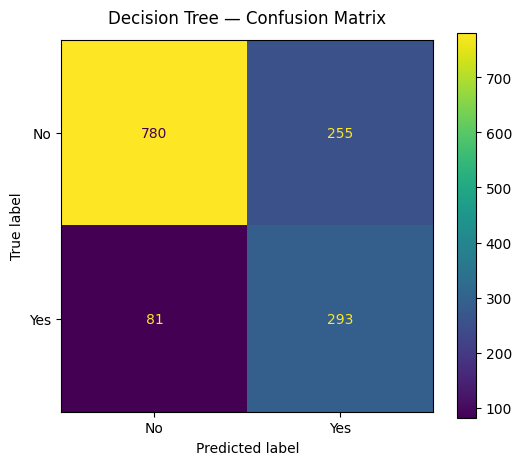

In [51]:
plot_confusion_matrix(
	best_dt_pipe,
	y_test,
	y_pred_dt,
	'Decision Tree — Confusion Matrix',
)

### ROC Curve Analysis

The ROC curve illustrates the Decision Tree classifier's discriminative capability across multiple classification thresholds.

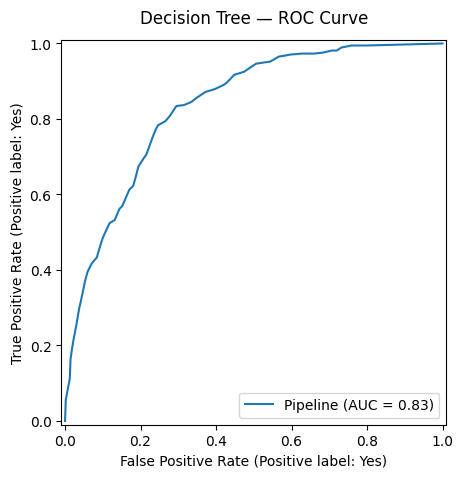

In [52]:
plot_roc_curve(
	best_dt_pipe,
	X_test,
	y_test,
	'Decision Tree — ROC Curve',
)

## Model Export and Saved Artifacts

The optimized Decision Tree pipeline and training metadata are exported for future inference and deployment workflows.

In [53]:
base_dt_path = 'models/decision_tree'

dt_artifacts = {
	'model_name': 'decision_tree',
	'best_params': dt_study.best_params,
	'best_cv_score': dt_study.best_value,
	'test_metrics': dt_metrics,
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
	'predict_time': dt_predict_time,
}

save_artifacts(base_dt_path, dt_artifacts, best_dt_pipe)

# Random Forest

This section trains an optimized Random Forest classifier using **Optuna** for hyperparameter search.

Random Forest is an ensemble method that builds multiple Decision Trees in parallel and aggregates their predictions through majority voting, reducing variance compared to a single tree.

Like the Decision Tree, numerical features are passed through **without scaling**, since tree-based models are invariant to feature magnitude.

> **Hardware note:** Trials run with `n_jobs=1` per trial to allow Optuna to parallelize across the CPU's threads via `n_jobs=-1`.

## Pipeline Definition

Each trial builds its own preprocessing + classifier pipeline from scratch to avoid state leakage between Optuna trials when `memory` caching is active.

Numerical features use `passthrough` (no scaling), while categorical features are one-hot encoded through the shared `cat_pipe` transformer.

## Optuna Objective Function

The objective function defines the **search space** and **evaluation strategy** for each trial.

For every trial, Optuna suggests a hyperparameter combination. The full pipeline is assembled and evaluated using the shared `RepeatedStratifiedKFold` strategy. The mean ROC-AUC across all folds is returned as the objective value to maximize.

Key parameters explored:
- `criterion` — impurity measure used for splitting
- `n_estimators` — number of trees in the forest (100–300, calibrated for training time)
- `max_depth` — maximum tree depth to control overfitting
- `min_samples_leaf` — minimum samples at each leaf node
- `max_features` — fraction of features considered at each split
- `class_weight` — balancing strategy to handle class imbalance

In [54]:
def objective(trial):
	criterion = trial.suggest_categorical(
		'criterion',
		['gini', 'entropy', 'log_loss'],
	)

	n_estimators = trial.suggest_int(
		'n_estimators',
		100,
		500,
	)

	max_depth = trial.suggest_int(
		'max_depth',
		2,
		20,
	)

	min_samples_leaf = trial.suggest_int(
		'min_samples_leaf',
		2,
		20,
	)

	max_features = trial.suggest_float(
		'max_features',
		0.2,
		1.0,
	)

	class_weight = trial.suggest_categorical(
		'class_weight',
		['balanced', 'balanced_subsample'],
	)

	rf_clf = RandomForestClassifier(
		n_estimators=n_estimators,
		criterion=criterion,
		max_depth=max_depth,
		min_samples_leaf=min_samples_leaf,
		max_features=max_features,
		class_weight=class_weight,
		random_state=RANDOM_STATE,
		n_jobs=1,
	)

	rf_prep = ColumnTransformer(
		transformers=[
			('num', 'passthrough', num_cols),
			('cat', cat_pipe, cat_cols),
		]
	)

	rf_pipe = Pipeline(
		steps=[
			('prep', rf_prep),
			('clf', rf_clf),
		],
		memory=memory,
	)

	scores = cross_val_score(
		rf_pipe,
		X_train,
		y_train,
		scoring='roc_auc',
		cv=rskf,
		n_jobs=1,
	)

	mean_roc_auc = scores.mean()

	return mean_roc_auc

## Optuna Study Configuration

A new Optuna study is created with `direction='maximize'` to search for the configuration that yields the highest mean cross-validation ROC-AUC.

Setting `gc_after_trial=True` releases memory between trials, preventing accumulation when fitting many parallel pipelines.

In [55]:
rf_study = optuna.create_study(direction='maximize')

[I 2026-05-25 21:45:15,471] A new study created in memory with name: no-name-790817eb-3281-4392-bd94-e5685fe77a15


In [56]:
rf_study.optimize(
	objective,
	n_trials=100,
	n_jobs=-1,
	gc_after_trial=True,
	show_progress_bar=True,
)

Best trial: 13. Best value: 0.845192:   1%|          | 1/100 [01:21<2:14:17, 81.39s/it]

[I 2026-05-25 21:46:36,721] Trial 13 finished with value: 0.8451919929059613 and parameters: {'criterion': 'log_loss', 'n_estimators': 137, 'max_depth': 18, 'min_samples_leaf': 10, 'max_features': 0.5896834341068078, 'class_weight': 'balanced'}. Best is trial 13 with value: 0.8451919929059613.


Best trial: 17. Best value: 0.847799:   2%|▏         | 2/100 [01:27<1:00:57, 37.32s/it]

[I 2026-05-25 21:46:43,202] Trial 17 finished with value: 0.8477989339600418 and parameters: {'criterion': 'gini', 'n_estimators': 154, 'max_depth': 8, 'min_samples_leaf': 18, 'max_features': 0.5671906266803186, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.8477989339600418.


Best trial: 17. Best value: 0.847799:   3%|▎         | 3/100 [01:58<55:15, 34.18s/it]  

[I 2026-05-25 21:47:13,618] Trial 18 finished with value: 0.8453664139447588 and parameters: {'criterion': 'gini', 'n_estimators': 204, 'max_depth': 8, 'min_samples_leaf': 3, 'max_features': 0.5787309609809648, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.8477989339600418.


Best trial: 17. Best value: 0.847799:   4%|▍         | 4/100 [02:00<34:43, 21.70s/it]

[I 2026-05-25 21:47:16,207] Trial 21 finished with value: 0.8464962005556612 and parameters: {'criterion': 'log_loss', 'n_estimators': 194, 'max_depth': 16, 'min_samples_leaf': 17, 'max_features': 0.8596648381572922, 'class_weight': 'balanced'}. Best is trial 17 with value: 0.8477989339600418.


Best trial: 17. Best value: 0.847799:   5%|▌         | 5/100 [02:05<24:33, 15.51s/it]

[I 2026-05-25 21:47:20,752] Trial 9 finished with value: 0.8354026030921133 and parameters: {'criterion': 'log_loss', 'n_estimators': 135, 'max_depth': 3, 'min_samples_leaf': 18, 'max_features': 0.6050167122247405, 'class_weight': 'balanced_subsample'}. Best is trial 17 with value: 0.8477989339600418.


Best trial: 20. Best value: 0.847929:   6%|▌         | 6/100 [02:31<29:55, 19.10s/it]

[I 2026-05-25 21:47:46,831] Trial 20 finished with value: 0.8479289882443491 and parameters: {'criterion': 'entropy', 'n_estimators': 164, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.2494766494523895, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:   7%|▋         | 7/100 [02:44<26:34, 17.15s/it]

[I 2026-05-25 21:47:59,961] Trial 14 finished with value: 0.8306151226076459 and parameters: {'criterion': 'entropy', 'n_estimators': 334, 'max_depth': 2, 'min_samples_leaf': 20, 'max_features': 0.5083056623728037, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:   8%|▊         | 8/100 [02:45<18:09, 11.84s/it]

[I 2026-05-25 21:48:00,423] Trial 7 finished with value: 0.8473819429095865 and parameters: {'criterion': 'log_loss', 'n_estimators': 172, 'max_depth': 10, 'min_samples_leaf': 14, 'max_features': 0.4983428013525238, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:   9%|▉         | 9/100 [02:51<15:35, 10.28s/it]

[I 2026-05-25 21:48:07,278] Trial 25 finished with value: 0.836589263610165 and parameters: {'criterion': 'gini', 'n_estimators': 153, 'max_depth': 3, 'min_samples_leaf': 11, 'max_features': 0.8475331325537492, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  10%|█         | 10/100 [03:01<14:55,  9.95s/it]

[I 2026-05-25 21:48:16,479] Trial 12 finished with value: 0.8432548534095907 and parameters: {'criterion': 'entropy', 'n_estimators': 329, 'max_depth': 4, 'min_samples_leaf': 20, 'max_features': 0.8843484785681632, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  11%|█         | 11/100 [03:02<10:58,  7.40s/it]

[I 2026-05-25 21:48:18,123] Trial 15 finished with value: 0.8444847613223985 and parameters: {'criterion': 'log_loss', 'n_estimators': 363, 'max_depth': 5, 'min_samples_leaf': 2, 'max_features': 0.28385092121055727, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  12%|█▏        | 12/100 [03:14<12:49,  8.74s/it]

[I 2026-05-25 21:48:29,914] Trial 0 finished with value: 0.8466848158456404 and parameters: {'criterion': 'log_loss', 'n_estimators': 197, 'max_depth': 16, 'min_samples_leaf': 16, 'max_features': 0.7088840794565532, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  13%|█▎        | 13/100 [03:35<18:13, 12.57s/it]

[I 2026-05-25 21:48:51,304] Trial 2 finished with value: 0.8477831846789613 and parameters: {'criterion': 'entropy', 'n_estimators': 232, 'max_depth': 17, 'min_samples_leaf': 17, 'max_features': 0.3754426077560822, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  14%|█▍        | 14/100 [03:52<19:41, 13.74s/it]

[I 2026-05-25 21:49:07,705] Trial 28 finished with value: 0.843022667781904 and parameters: {'criterion': 'log_loss', 'n_estimators': 108, 'max_depth': 10, 'min_samples_leaf': 3, 'max_features': 0.5004504094992228, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  15%|█▌        | 15/100 [03:57<15:35, 11.01s/it]

[I 2026-05-25 21:49:12,407] Trial 11 finished with value: 0.8441402852264188 and parameters: {'criterion': 'gini', 'n_estimators': 396, 'max_depth': 10, 'min_samples_leaf': 8, 'max_features': 0.7740487487308807, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  16%|█▌        | 16/100 [04:07<15:09, 10.83s/it]

[I 2026-05-25 21:49:22,827] Trial 22 finished with value: 0.8436939257087812 and parameters: {'criterion': 'gini', 'n_estimators': 399, 'max_depth': 18, 'min_samples_leaf': 10, 'max_features': 0.9427156384241595, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  17%|█▋        | 17/100 [04:19<15:17, 11.06s/it]

[I 2026-05-25 21:49:34,398] Trial 26 finished with value: 0.8473556587136544 and parameters: {'criterion': 'entropy', 'n_estimators': 266, 'max_depth': 6, 'min_samples_leaf': 6, 'max_features': 0.4578190957894223, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  18%|█▊        | 18/100 [04:21<11:27,  8.38s/it]

[I 2026-05-25 21:49:36,567] Trial 4 finished with value: 0.8458844356364831 and parameters: {'criterion': 'entropy', 'n_estimators': 456, 'max_depth': 5, 'min_samples_leaf': 8, 'max_features': 0.9990689493957068, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  19%|█▉        | 19/100 [04:21<08:09,  6.05s/it]

[I 2026-05-25 21:49:37,178] Trial 8 finished with value: 0.8452059744016232 and parameters: {'criterion': 'gini', 'n_estimators': 264, 'max_depth': 20, 'min_samples_leaf': 12, 'max_features': 0.8001256716207912, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  20%|██        | 20/100 [04:22<05:51,  4.39s/it]

[I 2026-05-25 21:49:37,697] Trial 16 finished with value: 0.8466000492795707 and parameters: {'criterion': 'log_loss', 'n_estimators': 460, 'max_depth': 19, 'min_samples_leaf': 13, 'max_features': 0.6342663701609883, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  21%|██        | 21/100 [04:30<07:10,  5.45s/it]

[I 2026-05-25 21:49:45,601] Trial 3 finished with value: 0.8390595701975115 and parameters: {'criterion': 'entropy', 'n_estimators': 451, 'max_depth': 15, 'min_samples_leaf': 4, 'max_features': 0.6102532940383375, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  22%|██▏       | 22/100 [04:34<06:40,  5.13s/it]

[I 2026-05-25 21:49:50,023] Trial 10 finished with value: 0.8471890120428806 and parameters: {'criterion': 'entropy', 'n_estimators': 285, 'max_depth': 6, 'min_samples_leaf': 6, 'max_features': 0.8138769754829924, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  23%|██▎       | 23/100 [05:11<18:39, 14.54s/it]

[I 2026-05-25 21:50:26,506] Trial 32 finished with value: 0.8361948235702873 and parameters: {'criterion': 'entropy', 'n_estimators': 271, 'max_depth': 3, 'min_samples_leaf': 20, 'max_features': 0.8626471092003483, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  24%|██▍       | 24/100 [05:51<28:07, 22.20s/it]

[I 2026-05-25 21:51:06,566] Trial 43 finished with value: 0.8473815970109199 and parameters: {'criterion': 'entropy', 'n_estimators': 100, 'max_depth': 13, 'min_samples_leaf': 15, 'max_features': 0.23581803849737015, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  25%|██▌       | 25/100 [05:52<20:04, 16.06s/it]

[I 2026-05-25 21:51:08,315] Trial 30 finished with value: 0.8408723467662559 and parameters: {'criterion': 'log_loss', 'n_estimators': 305, 'max_depth': 17, 'min_samples_leaf': 7, 'max_features': 0.9261733439331847, 'class_weight': 'balanced'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  26%|██▌       | 26/100 [05:53<14:00, 11.36s/it]

[I 2026-05-25 21:51:08,703] Trial 23 finished with value: 0.8450351822217814 and parameters: {'criterion': 'entropy', 'n_estimators': 400, 'max_depth': 5, 'min_samples_leaf': 9, 'max_features': 0.3397389142792493, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  27%|██▋       | 27/100 [06:07<14:48, 12.17s/it]

[I 2026-05-25 21:51:22,770] Trial 1 finished with value: 0.8475690085422805 and parameters: {'criterion': 'log_loss', 'n_estimators': 400, 'max_depth': 6, 'min_samples_leaf': 9, 'max_features': 0.6071136027569297, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  28%|██▊       | 28/100 [06:38<21:29, 17.91s/it]

[I 2026-05-25 21:51:54,057] Trial 19 finished with value: 0.8458257980466386 and parameters: {'criterion': 'log_loss', 'n_estimators': 416, 'max_depth': 8, 'min_samples_leaf': 5, 'max_features': 0.7407527725310088, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  29%|██▉       | 29/100 [06:49<18:33, 15.68s/it]

[I 2026-05-25 21:52:04,561] Trial 34 finished with value: 0.8476708588490989 and parameters: {'criterion': 'entropy', 'n_estimators': 260, 'max_depth': 13, 'min_samples_leaf': 15, 'max_features': 0.21992541792027515, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  30%|███       | 30/100 [07:03<17:49, 15.27s/it]

[I 2026-05-25 21:52:18,871] Trial 5 finished with value: 0.8357356183276162 and parameters: {'criterion': 'entropy', 'n_estimators': 478, 'max_depth': 3, 'min_samples_leaf': 16, 'max_features': 0.7119795626285024, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  31%|███       | 31/100 [07:27<20:42, 18.00s/it]

[I 2026-05-25 21:52:43,237] Trial 31 finished with value: 0.847782655329943 and parameters: {'criterion': 'entropy', 'n_estimators': 327, 'max_depth': 10, 'min_samples_leaf': 16, 'max_features': 0.21924164829151094, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  32%|███▏      | 32/100 [07:32<15:49, 13.96s/it]

[I 2026-05-25 21:52:47,774] Trial 36 finished with value: 0.8456796689008342 and parameters: {'criterion': 'gini', 'n_estimators': 271, 'max_depth': 13, 'min_samples_leaf': 7, 'max_features': 0.21090537466799786, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  33%|███▎      | 33/100 [07:39<13:20, 11.95s/it]

[I 2026-05-25 21:52:55,040] Trial 6 finished with value: 0.8365091024489331 and parameters: {'criterion': 'entropy', 'n_estimators': 443, 'max_depth': 17, 'min_samples_leaf': 4, 'max_features': 0.9680515494852202, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  34%|███▍      | 34/100 [07:41<09:48,  8.92s/it]

[I 2026-05-25 21:52:56,872] Trial 38 finished with value: 0.8471722069942801 and parameters: {'criterion': 'gini', 'n_estimators': 261, 'max_depth': 13, 'min_samples_leaf': 14, 'max_features': 0.20425666060435438, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  35%|███▌      | 35/100 [07:43<07:16,  6.72s/it]

[I 2026-05-25 21:52:58,471] Trial 29 finished with value: 0.8463459164254508 and parameters: {'criterion': 'log_loss', 'n_estimators': 329, 'max_depth': 7, 'min_samples_leaf': 3, 'max_features': 0.8154893935684275, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  36%|███▌      | 36/100 [07:53<08:21,  7.84s/it]

[I 2026-05-25 21:53:08,890] Trial 45 finished with value: 0.847595604838252 and parameters: {'criterion': 'entropy', 'n_estimators': 231, 'max_depth': 13, 'min_samples_leaf': 15, 'max_features': 0.22063942830061356, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  37%|███▋      | 37/100 [07:57<06:52,  6.55s/it]

[I 2026-05-25 21:53:12,452] Trial 42 finished with value: 0.8479230978078934 and parameters: {'criterion': 'entropy', 'n_estimators': 248, 'max_depth': 13, 'min_samples_leaf': 14, 'max_features': 0.25129201642929994, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  38%|███▊      | 38/100 [07:58<05:01,  4.86s/it]

[I 2026-05-25 21:53:13,383] Trial 24 finished with value: 0.847534167334971 and parameters: {'criterion': 'entropy', 'n_estimators': 456, 'max_depth': 8, 'min_samples_leaf': 13, 'max_features': 0.21458275686808614, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  39%|███▉      | 39/100 [07:59<03:59,  3.93s/it]

[I 2026-05-25 21:53:15,137] Trial 44 finished with value: 0.8476112858382912 and parameters: {'criterion': 'entropy', 'n_estimators': 243, 'max_depth': 13, 'min_samples_leaf': 15, 'max_features': 0.21950378438387827, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  40%|████      | 40/100 [08:09<05:32,  5.55s/it]

[I 2026-05-25 21:53:24,447] Trial 41 finished with value: 0.8473940079449436 and parameters: {'criterion': 'gini', 'n_estimators': 264, 'max_depth': 13, 'min_samples_leaf': 13, 'max_features': 0.21638856824752106, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  41%|████      | 41/100 [08:33<11:07, 11.31s/it]

[I 2026-05-25 21:53:49,191] Trial 46 finished with value: 0.8476074056386778 and parameters: {'criterion': 'entropy', 'n_estimators': 234, 'max_depth': 13, 'min_samples_leaf': 15, 'max_features': 0.21442300402557887, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  42%|████▏     | 42/100 [09:06<17:04, 17.67s/it]

[I 2026-05-25 21:54:21,709] Trial 47 finished with value: 0.8478669503758592 and parameters: {'criterion': 'gini', 'n_estimators': 220, 'max_depth': 12, 'min_samples_leaf': 18, 'max_features': 0.34890154419210123, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  43%|████▎     | 43/100 [09:09<12:35, 13.26s/it]

[I 2026-05-25 21:54:24,677] Trial 27 finished with value: 0.8435876825572768 and parameters: {'criterion': 'gini', 'n_estimators': 467, 'max_depth': 16, 'min_samples_leaf': 7, 'max_features': 0.52983627927811, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  44%|████▍     | 44/100 [09:13<09:51, 10.57s/it]

[I 2026-05-25 21:54:28,978] Trial 49 finished with value: 0.8478085342354013 and parameters: {'criterion': 'gini', 'n_estimators': 225, 'max_depth': 13, 'min_samples_leaf': 18, 'max_features': 0.3984653089724712, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 20. Best value: 0.847929:  45%|████▌     | 45/100 [09:19<08:20,  9.09s/it]

[I 2026-05-25 21:54:34,609] Trial 48 finished with value: 0.8478255040767299 and parameters: {'criterion': 'gini', 'n_estimators': 232, 'max_depth': 13, 'min_samples_leaf': 18, 'max_features': 0.3906362923889191, 'class_weight': 'balanced_subsample'}. Best is trial 20 with value: 0.8479289882443491.


Best trial: 50. Best value: 0.848047:  46%|████▌     | 46/100 [09:25<07:30,  8.35s/it]

[I 2026-05-25 21:54:41,230] Trial 50 finished with value: 0.8480469329494436 and parameters: {'criterion': 'gini', 'n_estimators': 224, 'max_depth': 13, 'min_samples_leaf': 18, 'max_features': 0.38113720004932816, 'class_weight': 'balanced_subsample'}. Best is trial 50 with value: 0.8480469329494436.


Best trial: 50. Best value: 0.848047:  47%|████▋     | 47/100 [09:50<11:47, 13.34s/it]

[I 2026-05-25 21:55:06,226] Trial 33 finished with value: 0.8437711925939354 and parameters: {'criterion': 'entropy', 'n_estimators': 467, 'max_depth': 14, 'min_samples_leaf': 5, 'max_features': 0.2527293635883397, 'class_weight': 'balanced_subsample'}. Best is trial 50 with value: 0.8480469329494436.


Best trial: 50. Best value: 0.848047:  48%|████▊     | 48/100 [09:54<09:09, 10.57s/it]

[I 2026-05-25 21:55:10,330] Trial 51 finished with value: 0.8479658896049704 and parameters: {'criterion': 'gini', 'n_estimators': 221, 'max_depth': 13, 'min_samples_leaf': 18, 'max_features': 0.40958874890159924, 'class_weight': 'balanced_subsample'}. Best is trial 50 with value: 0.8480469329494436.


Best trial: 50. Best value: 0.848047:  49%|████▉     | 49/100 [10:05<09:02, 10.63s/it]

[I 2026-05-25 21:55:21,102] Trial 35 finished with value: 0.8477099409049563 and parameters: {'criterion': 'gini', 'n_estimators': 480, 'max_depth': 12, 'min_samples_leaf': 14, 'max_features': 0.2092997641247198, 'class_weight': 'balanced_subsample'}. Best is trial 50 with value: 0.8480469329494436.


Best trial: 52. Best value: 0.848059:  50%|█████     | 50/100 [10:15<08:37, 10.35s/it]

[I 2026-05-25 21:55:30,808] Trial 52 finished with value: 0.8480588798849737 and parameters: {'criterion': 'gini', 'n_estimators': 236, 'max_depth': 13, 'min_samples_leaf': 18, 'max_features': 0.3802052109757874, 'class_weight': 'balanced_subsample'}. Best is trial 52 with value: 0.8480588798849737.


Best trial: 52. Best value: 0.848059:  51%|█████     | 51/100 [10:18<06:46,  8.30s/it]

[I 2026-05-25 21:55:34,318] Trial 37 finished with value: 0.8473081951843754 and parameters: {'criterion': 'gini', 'n_estimators': 454, 'max_depth': 13, 'min_samples_leaf': 12, 'max_features': 0.22662975039116476, 'class_weight': 'balanced_subsample'}. Best is trial 52 with value: 0.8480588798849737.


Best trial: 52. Best value: 0.848059:  52%|█████▏    | 52/100 [10:23<05:44,  7.17s/it]

[I 2026-05-25 21:55:38,855] Trial 53 finished with value: 0.8480483763266523 and parameters: {'criterion': 'gini', 'n_estimators': 227, 'max_depth': 13, 'min_samples_leaf': 18, 'max_features': 0.37066223473843474, 'class_weight': 'balanced_subsample'}. Best is trial 52 with value: 0.8480588798849737.


Best trial: 52. Best value: 0.848059:  53%|█████▎    | 53/100 [10:46<09:22, 11.98s/it]

[I 2026-05-25 21:56:02,044] Trial 54 finished with value: 0.8478983666881825 and parameters: {'criterion': 'gini', 'n_estimators': 226, 'max_depth': 12, 'min_samples_leaf': 17, 'max_features': 0.3542485901507733, 'class_weight': 'balanced_subsample'}. Best is trial 52 with value: 0.8480588798849737.


Best trial: 55. Best value: 0.848332:  54%|█████▍    | 54/100 [10:49<07:02,  9.19s/it]

[I 2026-05-25 21:56:04,730] Trial 55 finished with value: 0.848331920628867 and parameters: {'criterion': 'entropy', 'n_estimators': 223, 'max_depth': 8, 'min_samples_leaf': 18, 'max_features': 0.3705496968181418, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  55%|█████▌    | 55/100 [11:04<08:07, 10.84s/it]

[I 2026-05-25 21:56:19,421] Trial 57 finished with value: 0.8481233886675469 and parameters: {'criterion': 'entropy', 'n_estimators': 227, 'max_depth': 8, 'min_samples_leaf': 18, 'max_features': 0.4154153958261239, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  56%|█████▌    | 56/100 [11:05<05:48,  7.92s/it]

[I 2026-05-25 21:56:20,543] Trial 58 finished with value: 0.8481851558539681 and parameters: {'criterion': 'entropy', 'n_estimators': 228, 'max_depth': 11, 'min_samples_leaf': 18, 'max_features': 0.37416942159013206, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  57%|█████▋    | 57/100 [11:05<04:08,  5.77s/it]

[I 2026-05-25 21:56:21,286] Trial 39 finished with value: 0.8479547385978036 and parameters: {'criterion': 'entropy', 'n_estimators': 487, 'max_depth': 13, 'min_samples_leaf': 14, 'max_features': 0.2443883133765602, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  58%|█████▊    | 58/100 [11:06<03:00,  4.30s/it]

[I 2026-05-25 21:56:22,145] Trial 62 finished with value: 0.84806792385056 and parameters: {'criterion': 'entropy', 'n_estimators': 211, 'max_depth': 15, 'min_samples_leaf': 18, 'max_features': 0.37120812556677685, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  59%|█████▉    | 59/100 [11:07<02:07,  3.10s/it]

[I 2026-05-25 21:56:22,457] Trial 56 finished with value: 0.8483269090544002 and parameters: {'criterion': 'entropy', 'n_estimators': 234, 'max_depth': 8, 'min_samples_leaf': 18, 'max_features': 0.36377784976262684, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  60%|██████    | 60/100 [11:11<02:19,  3.48s/it]

[I 2026-05-25 21:56:26,829] Trial 59 finished with value: 0.8479116510138973 and parameters: {'criterion': 'entropy', 'n_estimators': 223, 'max_depth': 11, 'min_samples_leaf': 18, 'max_features': 0.35694086261951546, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  61%|██████    | 61/100 [11:14<02:11,  3.37s/it]

[I 2026-05-25 21:56:29,934] Trial 40 finished with value: 0.8478389794721402 and parameters: {'criterion': 'gini', 'n_estimators': 482, 'max_depth': 14, 'min_samples_leaf': 14, 'max_features': 0.253109199272149, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  62%|██████▏   | 62/100 [11:18<02:11,  3.46s/it]

[I 2026-05-25 21:56:33,588] Trial 63 finished with value: 0.84806792385056 and parameters: {'criterion': 'entropy', 'n_estimators': 211, 'max_depth': 15, 'min_samples_leaf': 18, 'max_features': 0.370894159051971, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  63%|██████▎   | 63/100 [11:21<02:00,  3.25s/it]

[I 2026-05-25 21:56:36,360] Trial 61 finished with value: 0.8480492503044466 and parameters: {'criterion': 'entropy', 'n_estimators': 229, 'max_depth': 15, 'min_samples_leaf': 18, 'max_features': 0.3715542381784457, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  64%|██████▍   | 64/100 [11:22<01:40,  2.80s/it]

[I 2026-05-25 21:56:38,088] Trial 60 finished with value: 0.8478777373151555 and parameters: {'criterion': 'entropy', 'n_estimators': 232, 'max_depth': 15, 'min_samples_leaf': 18, 'max_features': 0.35251369967968704, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  65%|██████▌   | 65/100 [11:32<02:49,  4.85s/it]

[I 2026-05-25 21:56:47,734] Trial 64 finished with value: 0.8481454221488578 and parameters: {'criterion': 'entropy', 'n_estimators': 199, 'max_depth': 11, 'min_samples_leaf': 18, 'max_features': 0.37205591088644707, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  66%|██████▌   | 66/100 [11:57<06:12, 10.95s/it]

[I 2026-05-25 21:57:12,923] Trial 65 finished with value: 0.8480401244797576 and parameters: {'criterion': 'gini', 'n_estimators': 191, 'max_depth': 15, 'min_samples_leaf': 18, 'max_features': 0.3737014406815976, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  67%|██████▋   | 67/100 [12:09<06:10, 11.24s/it]

[I 2026-05-25 21:57:24,844] Trial 66 finished with value: 0.848015707413764 and parameters: {'criterion': 'gini', 'n_estimators': 201, 'max_depth': 12, 'min_samples_leaf': 18, 'max_features': 0.37283850163299137, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  68%|██████▊   | 68/100 [12:15<05:06,  9.57s/it]

[I 2026-05-25 21:57:30,505] Trial 67 finished with value: 0.8478988785517839 and parameters: {'criterion': 'gini', 'n_estimators': 204, 'max_depth': 11, 'min_samples_leaf': 18, 'max_features': 0.39131603536661497, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  69%|██████▉   | 69/100 [12:19<04:04,  7.88s/it]

[I 2026-05-25 21:57:34,440] Trial 69 finished with value: 0.8479655688110646 and parameters: {'criterion': 'gini', 'n_estimators': 196, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.320246479534481, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  70%|███████   | 70/100 [12:20<02:57,  5.92s/it]

[I 2026-05-25 21:57:35,789] Trial 68 finished with value: 0.8479575762172228 and parameters: {'criterion': 'gini', 'n_estimators': 202, 'max_depth': 11, 'min_samples_leaf': 18, 'max_features': 0.41123033126661923, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  71%|███████   | 71/100 [12:40<04:58, 10.31s/it]

[I 2026-05-25 21:57:56,357] Trial 70 finished with value: 0.8479892543223805 and parameters: {'criterion': 'gini', 'n_estimators': 192, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.3189175583225113, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  72%|███████▏  | 72/100 [12:49<04:31,  9.69s/it]

[I 2026-05-25 21:58:04,574] Trial 71 finished with value: 0.8479655688110646 and parameters: {'criterion': 'gini', 'n_estimators': 196, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.32052597409337774, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  73%|███████▎  | 73/100 [13:05<05:12, 11.59s/it]

[I 2026-05-25 21:58:20,587] Trial 73 finished with value: 0.8479205682834738 and parameters: {'criterion': 'gini', 'n_estimators': 187, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.4376263778663919, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  73%|███████▎  | 73/100 [13:08<05:12, 11.59s/it]

[I 2026-05-25 21:58:23,949] Trial 72 finished with value: 0.8479468968278934 and parameters: {'criterion': 'gini', 'n_estimators': 205, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.3184864151562485, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.
[I 2026-05-25 21:58:23,955] Trial 75 finished with value: 0.8478567853899124 and parameters: {'criterion': 'gini', 'n_estimators': 186, 'max_depth': 15, 'min_samples_leaf': 19, 'max_features': 0.3011166813887791, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  76%|███████▌  | 76/100 [13:15<02:34,  6.44s/it]

[I 2026-05-25 21:58:30,632] Trial 74 finished with value: 0.8480120179907942 and parameters: {'criterion': 'gini', 'n_estimators': 199, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.3064161970984198, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  77%|███████▋  | 77/100 [13:31<03:22,  8.82s/it]

[I 2026-05-25 21:58:46,660] Trial 76 finished with value: 0.8479595800069282 and parameters: {'criterion': 'gini', 'n_estimators': 185, 'max_depth': 11, 'min_samples_leaf': 19, 'max_features': 0.29834189826270024, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  78%|███████▊  | 78/100 [13:47<03:56, 10.75s/it]

[I 2026-05-25 21:59:02,840] Trial 77 finished with value: 0.847859676735473 and parameters: {'criterion': 'gini', 'n_estimators': 197, 'max_depth': 15, 'min_samples_leaf': 19, 'max_features': 0.4389016669068099, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  79%|███████▉  | 79/100 [13:51<03:06,  8.87s/it]

[I 2026-05-25 21:59:06,717] Trial 79 finished with value: 0.8478484286305162 and parameters: {'criterion': 'gini', 'n_estimators': 188, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.3054381460406278, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  80%|████████  | 80/100 [13:53<02:22,  7.11s/it]

[I 2026-05-25 21:59:09,289] Trial 80 finished with value: 0.847833706104839 and parameters: {'criterion': 'gini', 'n_estimators': 190, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.3079818034683604, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  81%|████████  | 81/100 [13:54<01:41,  5.37s/it]

[I 2026-05-25 21:59:10,294] Trial 78 finished with value: 0.8478260807047525 and parameters: {'criterion': 'gini', 'n_estimators': 189, 'max_depth': 15, 'min_samples_leaf': 19, 'max_features': 0.4395977506478652, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  82%|████████▏ | 82/100 [13:55<01:12,  4.05s/it]

[I 2026-05-25 21:59:11,112] Trial 81 finished with value: 0.8480056728358148 and parameters: {'criterion': 'entropy', 'n_estimators': 192, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.31070473708570434, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  83%|████████▎ | 83/100 [13:58<01:00,  3.56s/it]

[I 2026-05-25 21:59:13,515] Trial 82 finished with value: 0.847898698715736 and parameters: {'criterion': 'entropy', 'n_estimators': 194, 'max_depth': 15, 'min_samples_leaf': 19, 'max_features': 0.29742062264576663, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  84%|████████▍ | 84/100 [14:00<00:52,  3.31s/it]

[I 2026-05-25 21:59:16,207] Trial 84 finished with value: 0.848016662273822 and parameters: {'criterion': 'entropy', 'n_estimators': 191, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.3158468337586621, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  85%|████████▌ | 85/100 [14:03<00:45,  3.00s/it]

[I 2026-05-25 21:59:18,480] Trial 85 finished with value: 0.8480061706329356 and parameters: {'criterion': 'entropy', 'n_estimators': 188, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.2955034301388949, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  86%|████████▌ | 86/100 [14:03<00:30,  2.18s/it]

[I 2026-05-25 21:59:18,739] Trial 87 finished with value: 0.8477589566313014 and parameters: {'criterion': 'entropy', 'n_estimators': 186, 'max_depth': 7, 'min_samples_leaf': 19, 'max_features': 0.3130951226284237, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  87%|████████▋ | 87/100 [14:05<00:26,  2.03s/it]

[I 2026-05-25 21:59:20,404] Trial 86 finished with value: 0.848016662273822 and parameters: {'criterion': 'entropy', 'n_estimators': 191, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.31354212537840753, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  88%|████████▊ | 88/100 [14:08<00:28,  2.34s/it]

[I 2026-05-25 21:59:23,492] Trial 83 finished with value: 0.8480517319637584 and parameters: {'criterion': 'entropy', 'n_estimators': 208, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.3065087164672788, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  89%|████████▉ | 89/100 [14:10<00:26,  2.37s/it]

[I 2026-05-25 21:59:25,931] Trial 88 finished with value: 0.848016662273822 and parameters: {'criterion': 'entropy', 'n_estimators': 191, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.3172569223606283, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  90%|█████████ | 90/100 [14:18<00:40,  4.04s/it]

[I 2026-05-25 21:59:33,891] Trial 89 finished with value: 0.8479965687946341 and parameters: {'criterion': 'entropy', 'n_estimators': 181, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.3074971687076746, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  91%|█████████ | 91/100 [14:23<00:39,  4.36s/it]

[I 2026-05-25 21:59:38,980] Trial 90 finished with value: 0.8478907637553916 and parameters: {'criterion': 'entropy', 'n_estimators': 176, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.43307924121097097, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  92%|█████████▏| 92/100 [14:26<00:31,  3.95s/it]

[I 2026-05-25 21:59:41,969] Trial 92 finished with value: 0.8478576192196264 and parameters: {'criterion': 'entropy', 'n_estimators': 174, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.4353527086472866, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  93%|█████████▎| 93/100 [14:27<00:20,  2.93s/it]

[I 2026-05-25 21:59:42,515] Trial 91 finished with value: 0.848012474565312 and parameters: {'criterion': 'entropy', 'n_estimators': 187, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.31303510769193277, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  94%|█████████▍| 94/100 [14:28<00:15,  2.54s/it]

[I 2026-05-25 21:59:44,145] Trial 93 finished with value: 0.8478967214960498 and parameters: {'criterion': 'entropy', 'n_estimators': 182, 'max_depth': 9, 'min_samples_leaf': 19, 'max_features': 0.44979762450391125, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  95%|█████████▌| 95/100 [14:31<00:13,  2.67s/it]

[I 2026-05-25 21:59:47,117] Trial 95 finished with value: 0.8479192185851187 and parameters: {'criterion': 'entropy', 'n_estimators': 171, 'max_depth': 9, 'min_samples_leaf': 17, 'max_features': 0.28780281539782393, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  96%|█████████▌| 96/100 [14:32<00:07,  1.98s/it]

[I 2026-05-25 21:59:47,501] Trial 94 finished with value: 0.8477354141292055 and parameters: {'criterion': 'entropy', 'n_estimators': 174, 'max_depth': 9, 'min_samples_leaf': 17, 'max_features': 0.44591422707688844, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  97%|█████████▋| 97/100 [14:36<00:08,  2.72s/it]

[I 2026-05-25 21:59:51,936] Trial 97 finished with value: 0.847822004355881 and parameters: {'criterion': 'entropy', 'n_estimators': 172, 'max_depth': 9, 'min_samples_leaf': 17, 'max_features': 0.4652478761387995, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  98%|█████████▊| 98/100 [14:37<00:04,  2.17s/it]

[I 2026-05-25 21:59:52,826] Trial 99 finished with value: 0.8478089197937284 and parameters: {'criterion': 'entropy', 'n_estimators': 171, 'max_depth': 9, 'min_samples_leaf': 17, 'max_features': 0.4661463247319959, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332:  99%|█████████▉| 99/100 [14:49<00:05,  5.14s/it]

[I 2026-05-25 22:00:04,884] Trial 98 finished with value: 0.8482575620862708 and parameters: {'criterion': 'entropy', 'n_estimators': 292, 'max_depth': 9, 'min_samples_leaf': 20, 'max_features': 0.45585607328248695, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


Best trial: 55. Best value: 0.848332: 100%|██████████| 100/100 [14:49<00:00,  8.90s/it]

[I 2026-05-25 22:00:05,113] Trial 96 finished with value: 0.8479350456225787 and parameters: {'criterion': 'entropy', 'n_estimators': 299, 'max_depth': 9, 'min_samples_leaf': 17, 'max_features': 0.4467147631133491, 'class_weight': 'balanced_subsample'}. Best is trial 55 with value: 0.848331920628867.


## Best Hyperparameters

The best Random Forest configuration identified by Optuna is analyzed below.

In [57]:
display(rf_study.best_params)

{'criterion': 'entropy',
 'n_estimators': 223,
 'max_depth': 8,
 'min_samples_leaf': 18,
 'max_features': 0.3705496968181418,
 'class_weight': 'balanced_subsample'}

## Cross-Validation Performance

The best mean ROC-AUC score obtained during hyperparameter optimization is displayed below.

In [58]:
display(rf_study.best_value)

0.848331920628867

## Best Pipeline Reconstruction

Optuna stores only the best **hyperparameter values**, not the fitted pipeline itself.

The best configuration is used to reconstruct and refit the Random Forest pipeline on the full training set before evaluation on the held-out test set.

In [59]:
best_rf_clf = RandomForestClassifier(
	**rf_study.best_params,
	random_state=RANDOM_STATE,
)

In [60]:
best_rf_prep = ColumnTransformer(
	transformers=[
		('num', 'passthrough', num_cols),
		('cat', cat_pipe, cat_cols),
	],
)

In [61]:
best_rf_pipe = Pipeline(
	steps=[
		('prep', best_rf_prep),
		('clf', best_rf_clf),
	],
	memory=memory,
)

In [62]:
best_rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(location=cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

## Test Set Inference

The optimized Random Forest pipeline is applied to the unseen test set to evaluate generalization performance.

Both class predictions and predicted probabilities are generated for downstream metric evaluation.

In [63]:
y_pred_rf = best_rf_pipe.predict(X_test)

rf_start = time.time()

y_proba_rf = best_rf_pipe.predict_proba(X_test)[:, 1]

rf_predict_time = time.time() - rf_start

## Model Evaluation Metrics

The optimized Random Forest model is evaluated using multiple classification metrics on the test set.

These metrics help analyze:

- Overall predictive performance
- Churn detection capability
- Balance between false positives and false negatives

In [64]:
rf_metrics = compute_metrics(y_test, y_pred_rf, y_proba_rf)

print_metrics(rf_metrics)

ROC-AUC  : 0.8436
PR-AUC   : 0.6534
Accuracy : 0.7594
Precision: 0.5314
Recall   : 0.7914
F1-Score : 0.6359


### Classification Report

A detailed classification report summarizes Random Forest performance across both churn classes.

In [65]:
display(build_classification_report(y_test, y_pred_rf))

,precision,recall,f1-score,support
No,0.908451,0.747826,0.820350,1035.000000
Yes,0.531418,0.791444,0.635875,374.000000
accuracy,0.759404,0.759404,0.759404,0.759404
macro avg,0.719935,0.769635,0.728113,1409.000000


### Confusion Matrix Analysis

The confusion matrix provides a detailed overview of correct and incorrect predictions produced by the Random Forest classifier.

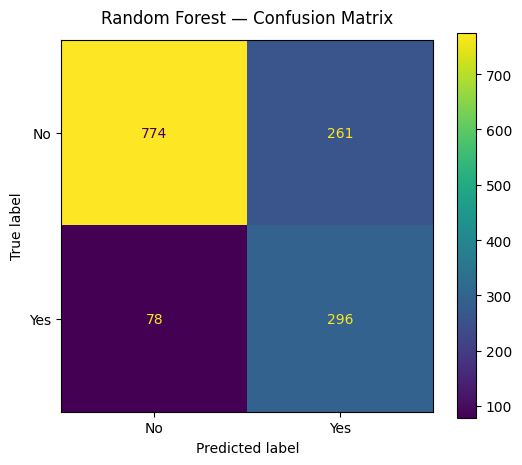

In [66]:
plot_confusion_matrix(
	best_rf_pipe,
	y_test,
	y_pred_rf,
	'Random Forest — Confusion Matrix',
)

### ROC Curve Analysis

The ROC curve illustrates the Random Forest classifier's discriminative capability across multiple classification thresholds.

Random Forest typically yields smoother probability estimates than a single Decision Tree, which tends to produce more reliable ROC curves.

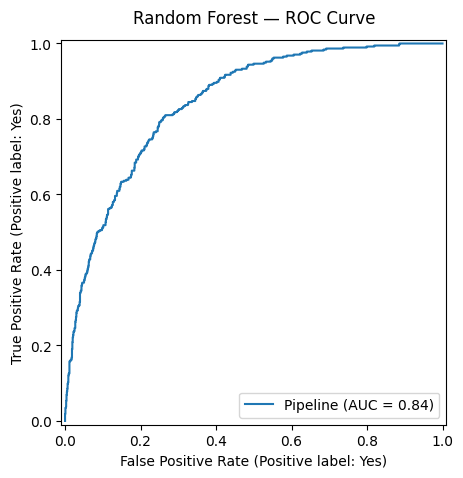

In [67]:
plot_roc_curve(
	best_rf_pipe,
	X_test,
	y_test,
	'Random Forest — ROC Curve',
)

## Model Export and Saved Artifacts

The optimized Random Forest pipeline and training metadata are exported for future inference and deployment workflows.

The following artifacts are persisted:

- Best trained Random Forest pipeline
- Best hyperparameter configuration
- Best cross-validation ROC-AUC score
- Training time

In [68]:
base_rf_path = 'models/random_forest'

rf_artifacts = {
	'model_name': 'random_forest',
	'best_params': rf_study.best_params,
	'best_cv_score': rf_study.best_value,
	'test_metrics': rf_metrics,
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
	'predict_time': rf_predict_time,
}

save_artifacts(base_rf_path, rf_artifacts, best_rf_pipe)

# XGBoost

This section trains an optimized XGBoost classifier using **Optuna** for hyperparameter search.

XGBoost (Extreme Gradient Boosting) builds trees sequentially, with each tree correcting the residual errors of the previous one. It is one of the most competitive algorithms for tabular classification tasks.

> **Hardware note:** XGBoost is configured with `tree_method='hist'` and `device='cuda'` when a GPU is available, leveraging the GPU to accelerate tree construction significantly. On CPU, the same `hist` method uses multi-threading across all cores.

## Class Imbalance Weight

XGBoost's `scale_pos_weight` parameter adjusts the weight assigned to the positive class (churned customers) to handle class imbalance.

Rather than including it in the Optuna search space, a principled value is computed directly from the training set class distribution.

This keeps the search space focused on structural hyperparameters and makes the imbalance handling explicit and interpretable.

In [69]:
# Ratio of negative to positive class in the training set
# XGBoost uses this to up-weight the minority class (churned customers)
scale = (y_train == 'No').sum() / (y_train == 'Yes').sum()

print(f'scale_pos_weight: {scale:.4f}')

scale_pos_weight: 2.7686


## Pipeline Definition

Each trial builds its own preprocessing + classifier pipeline from scratch to avoid state leakage between Optuna trials.

XGBoost does not require feature scaling; numerical features are passed through directly. Categorical features are one-hot encoded via the shared `cat_pipe`.

## Optuna Objective Function

The objective function defines the **search space** and **evaluation strategy** for each trial.

For every trial, the target variable is label-encoded (XGBoost expects integer labels), and the pipeline is evaluated using the shared `RepeatedStratifiedKFold` strategy.

Key parameters explored:
- `booster` — tree type: `gbtree` (standard) or `dart` (dropout regularization)
- `n_estimators` — number of boosting rounds
- `learning_rate` — step size shrinkage (log-scale)
- `max_depth` — maximum tree depth
- `min_child_weight` — minimum sum of instance weights in a leaf
- `gamma`, `reg_lambda`, `reg_alpha` — regularization terms (log-scale)
- `subsample`, `colsample_bytree` — row and column subsampling ratios
- `scale_pos_weight` — **fixed** from training distribution (not tuned)

In [70]:
def objective(trial):
	params = {
		'booster': trial.suggest_categorical(
			'booster',
			['gbtree', 'dart'],
		),
		'tree_method': 'hist',
		'device': 'cuda' if torch.cuda.is_available() else 'cpu',
		'verbosity': 0,
		'n_estimators': trial.suggest_int(
			'n_estimators',
			100,
			1000,
		),
		'learning_rate': trial.suggest_float(
			'learning_rate',
			1e-6,
			0.3,
			log=True,
		),
		'max_depth': trial.suggest_int(
			'max_depth',
			3,
			10,
		),
		'min_child_weight': trial.suggest_int(
			'min_child_weight',
			1,
			10,
		),
		'gamma': trial.suggest_float(
			'gamma',
			1e-6,
			1.0,
			log=True,
		),
		'reg_lambda': trial.suggest_float(
			'reg_lambda',
			1e-6,
			1.0,
			log=True,
		),
		'reg_alpha': trial.suggest_float(
			'reg_alpha',
			1e-6,
			1.0,
			log=True,
		),
		'subsample': trial.suggest_float(
			'subsample',
			0.5,
			1.0,
		),
		'colsample_bytree': trial.suggest_float(
			'colsample_bytree',
			0.5,
			1.0,
		),
		# scale_pos_weight is fixed based on the training class distribution
		# to handle imbalance without adding it to the search space
		'scale_pos_weight': scale,
	}

	if params['booster'] == 'dart':
		params['sample_type'] = trial.suggest_categorical(
			'sample_type',
			['uniform', 'weighted'],
		)
		params['normalize_type'] = trial.suggest_categorical(
			'normalize_type',
			['tree', 'forest'],
		)
		params['rate_drop'] = trial.suggest_float(
			'rate_drop',
			1e-6,
			0.5,
			log=True,
		)
		params['skip_drop'] = trial.suggest_float(
			'skip_drop',
			1e-6,
			0.5,
			log=True,
		)

	xgb_clf = XGBClassifier(
		**params,
		random_state=RANDOM_STATE,
		eval_metric='logloss',
	)

	xgb_prep = ColumnTransformer(
		transformers=[
			('num', 'passthrough', num_cols),
			('cat', cat_pipe, cat_cols),
		]
	)

	xgb_pipe = Pipeline(
		steps=[
			('prep', xgb_prep),
			('clf', xgb_clf),
		],
		memory=memory,
	)

	le = LabelEncoder()

	y_train_encoded = le.fit_transform(y_train)

	scores = cross_val_score(
		xgb_pipe,
		X_train,
		y_train_encoded,
		scoring='roc_auc',
		cv=rskf,
		n_jobs=1,
	)

	mean_roc_auc = scores.mean()

	return mean_roc_auc

## Optuna Study Configuration

A new Optuna study is created with `direction='maximize'` to find the configuration that yields the highest mean cross-validation ROC-AUC.

`gc_after_trial=True` ensures memory is released between trials, which is especially relevant when running many trials in parallel.

In [71]:
xgb_study = optuna.create_study(direction='maximize')

[I 2026-05-25 22:00:06,455] A new study created in memory with name: no-name-7c3f3e28-c0da-4811-8ee3-74f4db94494e


In [72]:
xgb_study.optimize(
	objective,
	n_trials=100,
	n_jobs=-1,
	gc_after_trial=True,
	show_progress_bar=True,
)

Best trial: 8. Best value: 0.837138:   1%|          | 1/100 [00:23<38:35, 23.39s/it]

[I 2026-05-25 22:00:29,746] Trial 8 finished with value: 0.8371380772187661 and parameters: {'booster': 'gbtree', 'n_estimators': 130, 'learning_rate': 0.00034239971179084416, 'max_depth': 3, 'min_child_weight': 9, 'gamma': 2.00391401965016e-05, 'reg_lambda': 0.09113171061805161, 'reg_alpha': 0.0008037244441810037, 'subsample': 0.637556647653768, 'colsample_bytree': 0.7224259665015136}. Best is trial 8 with value: 0.8371380772187661.


Best trial: 17. Best value: 0.848584:   2%|▏         | 2/100 [00:45<37:17, 22.84s/it]

[I 2026-05-25 22:00:52,193] Trial 17 finished with value: 0.8485842061828786 and parameters: {'booster': 'gbtree', 'n_estimators': 258, 'learning_rate': 0.009211753408953005, 'max_depth': 5, 'min_child_weight': 2, 'gamma': 0.023881219810445754, 'reg_lambda': 1.0181006177928417e-06, 'reg_alpha': 0.001557642011441858, 'subsample': 0.6023380628774548, 'colsample_bytree': 0.9682679881258813}. Best is trial 17 with value: 0.8485842061828786.


Best trial: 17. Best value: 0.848584:   3%|▎         | 3/100 [00:58<29:44, 18.40s/it]

[I 2026-05-25 22:01:05,311] Trial 1 finished with value: 0.844629766028906 and parameters: {'booster': 'gbtree', 'n_estimators': 349, 'learning_rate': 0.0012760442230035649, 'max_depth': 4, 'min_child_weight': 3, 'gamma': 2.3888796030205506e-06, 'reg_lambda': 0.7577852376100357, 'reg_alpha': 0.008340878687692318, 'subsample': 0.5786956100070522, 'colsample_bytree': 0.9350321943739823}. Best is trial 17 with value: 0.8485842061828786.


Best trial: 17. Best value: 0.848584:   4%|▍         | 4/100 [01:11<25:49, 16.15s/it]

[I 2026-05-25 22:01:17,993] Trial 12 finished with value: 0.8450038109417332 and parameters: {'booster': 'gbtree', 'n_estimators': 401, 'learning_rate': 1.2350701574173944e-05, 'max_depth': 6, 'min_child_weight': 1, 'gamma': 0.00020602983137709408, 'reg_lambda': 9.535279640111095e-06, 'reg_alpha': 0.09011950974014836, 'subsample': 0.9469582840924864, 'colsample_bytree': 0.5573158706793977}. Best is trial 17 with value: 0.8485842061828786.


Best trial: 22. Best value: 0.84974:   5%|▌         | 5/100 [01:19<20:56, 13.22s/it] 

[I 2026-05-25 22:01:26,042] Trial 22 finished with value: 0.8497395408438924 and parameters: {'booster': 'gbtree', 'n_estimators': 496, 'learning_rate': 0.012747903867849377, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.0003207397384506063, 'reg_lambda': 0.014763863013999514, 'reg_alpha': 0.005861325100384033, 'subsample': 0.7679542858599323, 'colsample_bytree': 0.9505973960248435}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:   6%|▌         | 6/100 [01:49<29:37, 18.91s/it]

[I 2026-05-25 22:01:55,996] Trial 14 finished with value: 0.8466693761248179 and parameters: {'booster': 'gbtree', 'n_estimators': 656, 'learning_rate': 3.086764580880343e-05, 'max_depth': 6, 'min_child_weight': 9, 'gamma': 1.3845561286839978e-05, 'reg_lambda': 2.1733158122508723e-06, 'reg_alpha': 1.053852924166309e-06, 'subsample': 0.7740028242658792, 'colsample_bytree': 0.817016668394702}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:   7%|▋         | 7/100 [02:07<28:54, 18.65s/it]

[I 2026-05-25 22:02:14,118] Trial 4 finished with value: 0.8079147440766978 and parameters: {'booster': 'gbtree', 'n_estimators': 815, 'learning_rate': 0.13911246327042665, 'max_depth': 4, 'min_child_weight': 2, 'gamma': 0.00010135522639069483, 'reg_lambda': 0.0022223824969301717, 'reg_alpha': 5.050000461311259e-06, 'subsample': 0.8035754369188655, 'colsample_bytree': 0.9869440674150521}. Best is trial 22 with value: 0.8497395408438924.
[I 2026-05-25 22:02:14,310] Trial 24 finished with value: 0.8474261097051468 and parameters: {'booster': 'gbtree', 'n_estimators': 643, 'learning_rate': 0.006798263842330744, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 0.056182369193210915, 'reg_lambda': 6.203001361601232e-05, 'reg_alpha': 1.7135273144289957e-06, 'subsample': 0.9449590362636683, 'colsample_bytree': 0.5833054862480059}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:   9%|▉         | 9/100 [02:09<14:03,  9.27s/it]

[I 2026-05-25 22:02:15,872] Trial 23 finished with value: 0.8450433445902299 and parameters: {'booster': 'gbtree', 'n_estimators': 613, 'learning_rate': 0.0001467080080976364, 'max_depth': 9, 'min_child_weight': 2, 'gamma': 0.009739587517098271, 'reg_lambda': 2.143104830916247e-05, 'reg_alpha': 0.35036732088569317, 'subsample': 0.6194341376758818, 'colsample_bytree': 0.6745030609359797}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  10%|█         | 10/100 [02:21<15:15, 10.17s/it]

[I 2026-05-25 22:02:28,045] Trial 11 finished with value: 0.7908933152000769 and parameters: {'booster': 'gbtree', 'n_estimators': 830, 'learning_rate': 0.12549747468180988, 'max_depth': 7, 'min_child_weight': 2, 'gamma': 0.2656310857480755, 'reg_lambda': 1.4416341520584042e-05, 'reg_alpha': 0.0007101267833640459, 'subsample': 0.5788600642466989, 'colsample_bytree': 0.8236624248186725}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  11%|█         | 11/100 [02:42<19:45, 13.32s/it]

[I 2026-05-25 22:02:48,511] Trial 9 finished with value: 0.8465208377034665 and parameters: {'booster': 'gbtree', 'n_estimators': 911, 'learning_rate': 5.504347457644658e-06, 'max_depth': 7, 'min_child_weight': 4, 'gamma': 9.327879244723055e-05, 'reg_lambda': 2.157398452899789e-06, 'reg_alpha': 0.0030666023110094286, 'subsample': 0.7554552606536139, 'colsample_bytree': 0.670088819223561}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  12%|█▏        | 12/100 [03:03<23:15, 15.85s/it]

[I 2026-05-25 22:03:10,166] Trial 31 finished with value: 0.8409237920863974 and parameters: {'booster': 'gbtree', 'n_estimators': 423, 'learning_rate': 0.0015532726487841823, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 0.00013155760198199244, 'reg_lambda': 0.2400104191809817, 'reg_alpha': 0.031155751139548042, 'subsample': 0.749117273280138, 'colsample_bytree': 0.7634634047160092}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  13%|█▎        | 13/100 [03:07<17:27, 12.04s/it]

[I 2026-05-25 22:03:13,432] Trial 13 finished with value: 0.8442977163986894 and parameters: {'booster': 'dart', 'n_estimators': 106, 'learning_rate': 1.3725304394416575e-05, 'max_depth': 5, 'min_child_weight': 5, 'gamma': 1.0665398186821742e-06, 'reg_lambda': 5.045812091882787e-06, 'reg_alpha': 0.08868286324845057, 'subsample': 0.9064284943559858, 'colsample_bytree': 0.5320658298181609, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 3.1584553060759287e-06, 'skip_drop': 5.184755651067683e-06}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  14%|█▍        | 14/100 [03:12<14:33, 10.16s/it]

[I 2026-05-25 22:03:19,230] Trial 32 finished with value: 0.8272310003899345 and parameters: {'booster': 'gbtree', 'n_estimators': 413, 'learning_rate': 0.05387370977086985, 'max_depth': 6, 'min_child_weight': 10, 'gamma': 0.0015252508155600708, 'reg_lambda': 0.0006095082312818532, 'reg_alpha': 0.001715252254822584, 'subsample': 0.87756242070902, 'colsample_bytree': 0.9783682275742238}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  15%|█▌        | 15/100 [04:27<41:59, 29.64s/it]

[I 2026-05-25 22:04:34,017] Trial 30 finished with value: 0.8481491778991911 and parameters: {'booster': 'gbtree', 'n_estimators': 998, 'learning_rate': 0.0021525966632540837, 'max_depth': 4, 'min_child_weight': 3, 'gamma': 1.9604914769170564e-06, 'reg_lambda': 0.18379948172432783, 'reg_alpha': 7.488679185662163e-05, 'subsample': 0.8298734599520905, 'colsample_bytree': 0.6144514621681454}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  16%|█▌        | 16/100 [06:05<1:10:04, 50.06s/it]

[I 2026-05-25 22:06:11,506] Trial 20 finished with value: 0.846768535240373 and parameters: {'booster': 'dart', 'n_estimators': 161, 'learning_rate': 0.008174149783544471, 'max_depth': 7, 'min_child_weight': 5, 'gamma': 0.32871107287862816, 'reg_lambda': 1.7327166179959837e-05, 'reg_alpha': 0.0210676626410091, 'subsample': 0.6352378995167295, 'colsample_bytree': 0.5678609955779191, 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 2.4800601410916144e-05, 'skip_drop': 3.190563238944323e-05}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  17%|█▋        | 17/100 [06:31<59:12, 42.80s/it]  

[I 2026-05-25 22:06:37,429] Trial 5 finished with value: 0.8468778086439345 and parameters: {'booster': 'dart', 'n_estimators': 167, 'learning_rate': 1.6749563418875978e-06, 'max_depth': 7, 'min_child_weight': 2, 'gamma': 0.7968663935698375, 'reg_lambda': 4.097946521037405e-06, 'reg_alpha': 0.00037573442549170715, 'subsample': 0.5037024380241673, 'colsample_bytree': 0.7817169183753856, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.00036081148308943054, 'skip_drop': 1.1833772960150242e-05}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  18%|█▊        | 18/100 [06:54<50:36, 37.03s/it]

[I 2026-05-25 22:07:01,007] Trial 35 finished with value: 0.8483337939128908 and parameters: {'booster': 'dart', 'n_estimators': 134, 'learning_rate': 0.021632668567156343, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 0.003998766168992417, 'reg_lambda': 0.00846227119416832, 'reg_alpha': 7.01375939613382e-05, 'subsample': 0.5166940515616965, 'colsample_bytree': 0.9130110150706348, 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 4.097763523799522e-05, 'skip_drop': 1.8464395401907881e-06}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 22. Best value: 0.84974:  19%|█▉        | 19/100 [08:10<1:05:51, 48.78s/it]

[I 2026-05-25 22:08:17,160] Trial 6 finished with value: 0.842083567359521 and parameters: {'booster': 'dart', 'n_estimators': 189, 'learning_rate': 0.0028423119124205607, 'max_depth': 9, 'min_child_weight': 6, 'gamma': 7.704286185683998e-06, 'reg_lambda': 0.03129385757762796, 'reg_alpha': 0.01660809543131247, 'subsample': 0.9330296252839321, 'colsample_bytree': 0.8655827182281811, 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 6.342408468909704e-05, 'skip_drop': 0.007304011614437824}. Best is trial 22 with value: 0.8497395408438924.


Best trial: 42. Best value: 0.849846:  20%|██        | 20/100 [08:48<1:00:35, 45.44s/it]

[I 2026-05-25 22:08:54,844] Trial 42 finished with value: 0.8498460962908038 and parameters: {'booster': 'gbtree', 'n_estimators': 286, 'learning_rate': 0.0199470889771473, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 0.022108559882195258, 'reg_lambda': 0.0002862435198418281, 'reg_alpha': 0.0001328849473687606, 'subsample': 0.6933411405644708, 'colsample_bytree': 0.9002362192226351}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  21%|██        | 21/100 [10:23<1:19:24, 60.31s/it]

[I 2026-05-25 22:10:29,822] Trial 43 finished with value: 0.8202273703978455 and parameters: {'booster': 'gbtree', 'n_estimators': 517, 'learning_rate': 0.03509156485545997, 'max_depth': 10, 'min_child_weight': 8, 'gamma': 0.0004615295094245551, 'reg_lambda': 0.00024376334672488646, 'reg_alpha': 0.00011138021291538798, 'subsample': 0.6889597497441333, 'colsample_bytree': 0.8885732270866094}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  22%|██▏       | 22/100 [10:59<1:09:07, 53.17s/it]

[I 2026-05-25 22:11:06,357] Trial 44 finished with value: 0.8494427211051971 and parameters: {'booster': 'gbtree', 'n_estimators': 278, 'learning_rate': 0.012343988752013346, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 0.034810488526516914, 'reg_lambda': 0.004841242026164211, 'reg_alpha': 1.825614942475164e-05, 'subsample': 0.6912091015659098, 'colsample_bytree': 0.951782376888728}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  23%|██▎       | 23/100 [11:21<55:52, 43.54s/it]  

[I 2026-05-25 22:11:27,423] Trial 37 finished with value: 0.8454985523149315 and parameters: {'booster': 'dart', 'n_estimators': 249, 'learning_rate': 0.012185188456315733, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 0.005508415961540381, 'reg_lambda': 0.01931353141234999, 'reg_alpha': 7.994494626439965e-05, 'subsample': 0.6683011909664898, 'colsample_bytree': 0.894701614187135, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.48197043750775864, 'skip_drop': 0.14066234674380262}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  24%|██▍       | 24/100 [11:36<44:38, 35.25s/it]

[I 2026-05-25 22:11:43,328] Trial 45 finished with value: 0.8217641512849212 and parameters: {'booster': 'gbtree', 'n_estimators': 280, 'learning_rate': 0.2828948970981503, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 0.061559889566590094, 'reg_lambda': 0.004137669888995862, 'reg_alpha': 1.4161949465431233e-05, 'subsample': 0.7093917100032439, 'colsample_bytree': 0.9347943358559315}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  25%|██▌       | 25/100 [12:02<40:25, 32.34s/it]

[I 2026-05-25 22:12:08,872] Trial 46 finished with value: 0.8272544887751535 and parameters: {'booster': 'gbtree', 'n_estimators': 305, 'learning_rate': 0.20882946948068312, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.07673017973896434, 'reg_lambda': 0.0030593891609999556, 'reg_alpha': 1.662089845010038e-05, 'subsample': 0.7055593136628605, 'colsample_bytree': 0.9430370850953661}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  26%|██▌       | 26/100 [12:47<44:39, 36.22s/it]

[I 2026-05-25 22:12:54,143] Trial 47 finished with value: 0.837927644993131 and parameters: {'booster': 'gbtree', 'n_estimators': 540, 'learning_rate': 0.06434741158548511, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.0009674213307770414, 'reg_lambda': 0.0009319381524718356, 'reg_alpha': 1.1659463701843714e-05, 'subsample': 0.72153942623698, 'colsample_bytree': 0.8514794751753101}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  27%|██▋       | 27/100 [12:50<31:49, 26.16s/it]

[I 2026-05-25 22:12:56,846] Trial 34 finished with value: 0.8472060394200227 and parameters: {'booster': 'dart', 'n_estimators': 227, 'learning_rate': 0.010001098699472619, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 0.002787736837155496, 'reg_lambda': 0.001886199548219249, 'reg_alpha': 6.785816724918537e-05, 'subsample': 0.6880968696655131, 'colsample_bytree': 0.8981849473866927, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.0016382733449080973, 'skip_drop': 0.1546660637470825}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  28%|██▊       | 28/100 [13:17<31:43, 26.44s/it]

[I 2026-05-25 22:13:23,927] Trial 48 finished with value: 0.8343456297622974 and parameters: {'booster': 'gbtree', 'n_estimators': 507, 'learning_rate': 0.055191091027388714, 'max_depth': 4, 'min_child_weight': 7, 'gamma': 0.0014043625845898996, 'reg_lambda': 0.0003029573949587247, 'reg_alpha': 1.4410288930196374e-05, 'subsample': 0.8409514427460446, 'colsample_bytree': 0.8440025385483264}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  29%|██▉       | 29/100 [13:27<25:25, 21.48s/it]

[I 2026-05-25 22:13:33,852] Trial 39 finished with value: 0.8468599421621482 and parameters: {'booster': 'dart', 'n_estimators': 235, 'learning_rate': 0.015644784710607058, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 0.008706285466591811, 'reg_lambda': 0.011538343852721305, 'reg_alpha': 7.239009052749407e-05, 'subsample': 0.5008280309173855, 'colsample_bytree': 0.9018628885439854, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.47717592188295677, 'skip_drop': 0.10602963612259661}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  30%|███       | 30/100 [13:49<25:21, 21.73s/it]

[I 2026-05-25 22:13:56,158] Trial 38 finished with value: 0.8455309846374298 and parameters: {'booster': 'dart', 'n_estimators': 269, 'learning_rate': 0.011930573972263296, 'max_depth': 9, 'min_child_weight': 7, 'gamma': 0.003648563750815506, 'reg_lambda': 0.011217173011044914, 'reg_alpha': 0.00012934182553516827, 'subsample': 0.6799504828845544, 'colsample_bytree': 0.9036171888371345, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.48239908658315095, 'skip_drop': 0.1388192782050842}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  31%|███       | 31/100 [14:01<21:35, 18.77s/it]

[I 2026-05-25 22:14:08,013] Trial 49 finished with value: 0.8400245189502945 and parameters: {'booster': 'gbtree', 'n_estimators': 471, 'learning_rate': 0.00010634668298703971, 'max_depth': 4, 'min_child_weight': 7, 'gamma': 0.0030857927062847767, 'reg_lambda': 0.00015822988071427063, 'reg_alpha': 0.0003685806714226075, 'subsample': 0.8583566773796174, 'colsample_bytree': 0.9979178879105437}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  32%|███▏      | 32/100 [14:07<16:44, 14.77s/it]

[I 2026-05-25 22:14:13,443] Trial 50 finished with value: 0.8421470968610629 and parameters: {'booster': 'gbtree', 'n_estimators': 476, 'learning_rate': 0.0005275141267941597, 'max_depth': 4, 'min_child_weight': 10, 'gamma': 0.020724649924433534, 'reg_lambda': 0.00013406406985733724, 'reg_alpha': 0.00023167963811953734, 'subsample': 0.8534851856385661, 'colsample_bytree': 0.8120931848231249}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  33%|███▎      | 33/100 [14:11<13:02, 11.68s/it]

[I 2026-05-25 22:14:17,921] Trial 51 finished with value: 0.841617503926062 and parameters: {'booster': 'gbtree', 'n_estimators': 342, 'learning_rate': 0.0003930453069169257, 'max_depth': 4, 'min_child_weight': 10, 'gamma': 0.02253341439319483, 'reg_lambda': 0.00011148753874331951, 'reg_alpha': 0.0002846421850275387, 'subsample': 0.7804338849334652, 'colsample_bytree': 0.9958945320487188}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  34%|███▍      | 34/100 [14:19<11:43, 10.66s/it]

[I 2026-05-25 22:14:26,190] Trial 52 finished with value: 0.8420547153470832 and parameters: {'booster': 'gbtree', 'n_estimators': 332, 'learning_rate': 0.0005994472782477754, 'max_depth': 4, 'min_child_weight': 10, 'gamma': 0.023747555166988028, 'reg_lambda': 8.116781865325278e-05, 'reg_alpha': 0.004554730974579386, 'subsample': 0.7828723586389951, 'colsample_bytree': 0.9478484294950343}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  35%|███▌      | 35/100 [14:45<16:32, 15.26s/it]

[I 2026-05-25 22:14:52,201] Trial 53 finished with value: 0.8417976446498697 and parameters: {'booster': 'gbtree', 'n_estimators': 352, 'learning_rate': 0.0004475124323333888, 'max_depth': 4, 'min_child_weight': 10, 'gamma': 0.017227734580868896, 'reg_lambda': 0.00016533688766653804, 'reg_alpha': 0.0078967516801233, 'subsample': 0.7893504976354431, 'colsample_bytree': 0.9492426348195514}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  36%|███▌      | 36/100 [14:57<15:00, 14.07s/it]

[I 2026-05-25 22:15:03,491] Trial 54 finished with value: 0.8478104592918883 and parameters: {'booster': 'gbtree', 'n_estimators': 347, 'learning_rate': 0.0038184005413595267, 'max_depth': 4, 'min_child_weight': 9, 'gamma': 0.02067088025309934, 'reg_lambda': 0.05834587635495207, 'reg_alpha': 0.002086300882911078, 'subsample': 0.589760047855046, 'colsample_bytree': 0.9515587689599357}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  37%|███▋      | 37/100 [15:00<11:32, 11.00s/it]

[I 2026-05-25 22:15:07,322] Trial 55 finished with value: 0.849232458185286 and parameters: {'booster': 'gbtree', 'n_estimators': 334, 'learning_rate': 0.00506877763391506, 'max_depth': 5, 'min_child_weight': 9, 'gamma': 0.02116183648253993, 'reg_lambda': 0.07547408789744908, 'reg_alpha': 0.0031997033566089194, 'subsample': 0.5697583626512717, 'colsample_bytree': 0.9624483724154175}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  38%|███▊      | 38/100 [15:09<10:26, 10.11s/it]

[I 2026-05-25 22:15:15,360] Trial 56 finished with value: 0.8485152539553625 and parameters: {'booster': 'gbtree', 'n_estimators': 354, 'learning_rate': 0.00329971427885754, 'max_depth': 5, 'min_child_weight': 9, 'gamma': 0.1606187812893484, 'reg_lambda': 0.047658886269021976, 'reg_alpha': 0.004203326867911747, 'subsample': 0.5852657573669237, 'colsample_bytree': 0.9548069806394072}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  39%|███▉      | 39/100 [15:20<10:45, 10.58s/it]

[I 2026-05-25 22:15:27,050] Trial 57 finished with value: 0.8469940789494121 and parameters: {'booster': 'gbtree', 'n_estimators': 365, 'learning_rate': 0.0043240285539005024, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 0.15835513754827218, 'reg_lambda': 0.004878108720660348, 'reg_alpha': 0.00849921903361547, 'subsample': 0.99031228802396, 'colsample_bytree': 0.9628141710918228}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  40%|████      | 40/100 [15:38<12:46, 12.78s/it]

[I 2026-05-25 22:15:44,941] Trial 61 finished with value: 0.8496944229002618 and parameters: {'booster': 'gbtree', 'n_estimators': 203, 'learning_rate': 0.030913603548452313, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 4.3862001608248183e-05, 'reg_lambda': 0.9777843094219508, 'reg_alpha': 4.481207269986058e-06, 'subsample': 0.5292780151554096, 'colsample_bytree': 0.9234944421249062}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  41%|████      | 41/100 [16:06<16:54, 17.19s/it]

[I 2026-05-25 22:16:12,437] Trial 63 finished with value: 0.8431048815747879 and parameters: {'booster': 'gbtree', 'n_estimators': 188, 'learning_rate': 0.10117548027175742, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 3.231592722025296e-05, 'reg_lambda': 0.6143523394974372, 'reg_alpha': 5.574713586869291e-06, 'subsample': 0.7432799003902638, 'colsample_bytree': 0.9245938104371219}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  42%|████▏     | 42/100 [16:20<15:45, 16.31s/it]

[I 2026-05-25 22:16:26,686] Trial 58 finished with value: 0.847877362111321 and parameters: {'booster': 'gbtree', 'n_estimators': 591, 'learning_rate': 0.004361440060391403, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 0.1541455016764214, 'reg_lambda': 0.05439168738769809, 'reg_alpha': 0.0013266566704965353, 'subsample': 0.9890314824581925, 'colsample_bytree': 0.9674083597936923}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  43%|████▎     | 43/100 [16:24<12:01, 12.66s/it]

[I 2026-05-25 22:16:30,821] Trial 60 finished with value: 0.8465263400418138 and parameters: {'booster': 'gbtree', 'n_estimators': 593, 'learning_rate': 0.003335201982729389, 'max_depth': 3, 'min_child_weight': 9, 'gamma': 0.18935432387736625, 'reg_lambda': 0.05842469581955882, 'reg_alpha': 5.3975333613602285e-06, 'subsample': 0.6532158275654982, 'colsample_bytree': 0.8724064463862851}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  44%|████▍     | 44/100 [16:43<13:36, 14.58s/it]

[I 2026-05-25 22:16:49,900] Trial 62 finished with value: 0.8412028479113942 and parameters: {'booster': 'gbtree', 'n_estimators': 592, 'learning_rate': 0.0011912096183081685, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.868604908752189, 'reg_lambda': 0.3777378542033092, 'reg_alpha': 3.136064535517936e-05, 'subsample': 0.654705767049985, 'colsample_bytree': 0.8677235417772136}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 42. Best value: 0.849846:  45%|████▌     | 45/100 [16:48<10:41, 11.66s/it]

[I 2026-05-25 22:16:54,741] Trial 59 finished with value: 0.8490898886405569 and parameters: {'booster': 'gbtree', 'n_estimators': 710, 'learning_rate': 0.004030015955228838, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 0.12642085061064143, 'reg_lambda': 1.0480815804298428e-06, 'reg_alpha': 2.8135279054092456e-05, 'subsample': 0.5392992411236702, 'colsample_bytree': 0.970715161191985}. Best is trial 42 with value: 0.8498460962908038.


Best trial: 66. Best value: 0.849985:  46%|████▌     | 46/100 [16:50<07:57,  8.85s/it]

[I 2026-05-25 22:16:57,019] Trial 66 finished with value: 0.8499853928390009 and parameters: {'booster': 'gbtree', 'n_estimators': 174, 'learning_rate': 0.021746948470641767, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 6.426216092321964e-05, 'reg_lambda': 0.18376292871652358, 'reg_alpha': 0.0005694054000759508, 'subsample': 0.5307697547387099, 'colsample_bytree': 0.9191287405245564}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  47%|████▋     | 47/100 [17:19<13:09, 14.90s/it]

[I 2026-05-25 22:17:26,045] Trial 68 finished with value: 0.8497503012131695 and parameters: {'booster': 'gbtree', 'n_estimators': 206, 'learning_rate': 0.02458147105526433, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 4.842389755367802e-05, 'reg_lambda': 0.12213362511808028, 'reg_alpha': 2.505739677309765e-06, 'subsample': 0.5673389800417457, 'colsample_bytree': 0.9238089076216714}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  48%|████▊     | 48/100 [17:22<09:50, 11.35s/it]

[I 2026-05-25 22:17:29,105] Trial 67 finished with value: 0.8445203620219793 and parameters: {'booster': 'gbtree', 'n_estimators': 209, 'learning_rate': 0.020118682273653904, 'max_depth': 8, 'min_child_weight': 8, 'gamma': 5.348508757702296e-05, 'reg_lambda': 0.922252577686339, 'reg_alpha': 3.289105984675314e-05, 'subsample': 0.5466141329152691, 'colsample_bytree': 0.9235742338037568}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  49%|████▉     | 49/100 [17:23<06:59,  8.23s/it]

[I 2026-05-25 22:17:30,074] Trial 7 finished with value: 0.8460295252302942 and parameters: {'booster': 'dart', 'n_estimators': 304, 'learning_rate': 0.00011699180240381598, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 0.002270350296553281, 'reg_lambda': 0.25347310972943843, 'reg_alpha': 2.192504015699524e-05, 'subsample': 0.6985604588944139, 'colsample_bytree': 0.5768666475519353, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.13919683953845305, 'skip_drop': 0.13555908822980142}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  50%|█████     | 50/100 [17:30<06:22,  7.66s/it]

[I 2026-05-25 22:17:36,379] Trial 69 finished with value: 0.8423854780896883 and parameters: {'booster': 'gbtree', 'n_estimators': 208, 'learning_rate': 0.02364141109132721, 'max_depth': 8, 'min_child_weight': 6, 'gamma': 4.277601185540756e-05, 'reg_lambda': 0.7310879506275452, 'reg_alpha': 3.2264141357508374e-06, 'subsample': 0.5590391179349892, 'colsample_bytree': 0.7326380489295824}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  51%|█████     | 51/100 [17:30<04:32,  5.57s/it]

[I 2026-05-25 22:17:37,074] Trial 64 finished with value: 0.8453588368981996 and parameters: {'booster': 'gbtree', 'n_estimators': 582, 'learning_rate': 0.02911443307451053, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 3.943334791549773e-05, 'reg_lambda': 0.6120283790228752, 'reg_alpha': 3.7087186011416237e-06, 'subsample': 0.5368675569724776, 'colsample_bytree': 0.8708857768000932}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  52%|█████▏    | 52/100 [17:39<05:13,  6.53s/it]

[I 2026-05-25 22:17:45,856] Trial 71 finished with value: 0.8491662707050048 and parameters: {'booster': 'gbtree', 'n_estimators': 112, 'learning_rate': 0.028520346777884675, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 7.652732462354477e-06, 'reg_lambda': 0.15085674226839127, 'reg_alpha': 2.544969071351934e-06, 'subsample': 0.556986095174192, 'colsample_bytree': 0.7836953969388729}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  53%|█████▎    | 53/100 [17:45<05:01,  6.41s/it]

[I 2026-05-25 22:17:51,989] Trial 74 finished with value: 0.8477125001252795 and parameters: {'booster': 'gbtree', 'n_estimators': 100, 'learning_rate': 0.08850624862573285, 'max_depth': 3, 'min_child_weight': 5, 'gamma': 7.713830023714936e-06, 'reg_lambda': 0.11987755245053824, 'reg_alpha': 1.7202536786434773e-06, 'subsample': 0.5280883951125884, 'colsample_bytree': 0.7908839121210771}. Best is trial 66 with value: 0.8499853928390009.
[I 2026-05-25 22:17:52,146] Trial 70 finished with value: 0.8499705745831081 and parameters: {'booster': 'gbtree', 'n_estimators': 184, 'learning_rate': 0.028061282143845005, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 4.153505816699856e-05, 'reg_lambda': 0.8010578245318286, 'reg_alpha': 1.6866142534405484e-06, 'subsample': 0.5498412959112822, 'colsample_bytree': 0.7316177633065482}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  55%|█████▌    | 55/100 [17:46<02:31,  3.36s/it]

[I 2026-05-25 22:17:52,765] Trial 72 finished with value: 0.8499126680595218 and parameters: {'booster': 'gbtree', 'n_estimators': 155, 'learning_rate': 0.030878282178690528, 'max_depth': 3, 'min_child_weight': 5, 'gamma': 6.305529433220932e-06, 'reg_lambda': 0.18396267975520714, 'reg_alpha': 2.347607319987816e-06, 'subsample': 0.5460497101794561, 'colsample_bytree': 0.7831659680461164}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  56%|█████▌    | 56/100 [17:51<02:53,  3.94s/it]

[I 2026-05-25 22:17:58,062] Trial 73 finished with value: 0.8499665205061643 and parameters: {'booster': 'gbtree', 'n_estimators': 146, 'learning_rate': 0.03624591691713656, 'max_depth': 3, 'min_child_weight': 5, 'gamma': 1.1276599184214366e-05, 'reg_lambda': 0.13905940063055386, 'reg_alpha': 0.0007330216119968931, 'subsample': 0.5266193181288896, 'colsample_bytree': 0.7935664425287522}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  57%|█████▋    | 57/100 [18:02<04:13,  5.91s/it]

[I 2026-05-25 22:18:08,552] Trial 75 finished with value: 0.8447272795615932 and parameters: {'booster': 'gbtree', 'n_estimators': 160, 'learning_rate': 0.09230275512228826, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 0.000283235108864045, 'reg_lambda': 0.025451811007873144, 'reg_alpha': 1.0804565868841435e-06, 'subsample': 0.6117022587070877, 'colsample_bytree': 0.9296635057783773}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  58%|█████▊    | 58/100 [18:02<03:03,  4.37s/it]

[I 2026-05-25 22:18:09,349] Trial 65 finished with value: 0.8433663792083662 and parameters: {'booster': 'gbtree', 'n_estimators': 727, 'learning_rate': 0.028895534681537896, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.0004217601150104547, 'reg_lambda': 0.9479079871784406, 'reg_alpha': 2.8870897699583197e-05, 'subsample': 0.5493162186440609, 'colsample_bytree': 0.8708126634951795}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  59%|█████▉    | 59/100 [18:06<02:54,  4.25s/it]

[I 2026-05-25 22:18:13,294] Trial 76 finished with value: 0.8350814216741922 and parameters: {'booster': 'gbtree', 'n_estimators': 151, 'learning_rate': 1.1970933285577698e-06, 'max_depth': 3, 'min_child_weight': 5, 'gamma': 0.00022276991841525275, 'reg_lambda': 0.021784029139357664, 'reg_alpha': 7.599944234830697e-06, 'subsample': 0.8068656360003195, 'colsample_bytree': 0.9251516831263676}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  60%|██████    | 60/100 [18:08<02:13,  3.33s/it]

[I 2026-05-25 22:18:14,497] Trial 78 finished with value: 0.8481684966474203 and parameters: {'booster': 'gbtree', 'n_estimators': 148, 'learning_rate': 0.043735288014270186, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 0.0003081187497351277, 'reg_lambda': 0.027331453668467037, 'reg_alpha': 1.2547673125033026e-06, 'subsample': 0.6119819161815931, 'colsample_bytree': 0.7203093586783397}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  61%|██████    | 61/100 [18:09<01:44,  2.67s/it]

[I 2026-05-25 22:18:15,617] Trial 77 finished with value: 0.8480920205133833 and parameters: {'booster': 'gbtree', 'n_estimators': 159, 'learning_rate': 0.04264285366089204, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 0.00037250310814875747, 'reg_lambda': 0.3534519746114069, 'reg_alpha': 1.0657427888918965e-06, 'subsample': 0.6025373989159855, 'colsample_bytree': 0.6914917615517364}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  62%|██████▏   | 62/100 [18:15<02:27,  3.87s/it]

[I 2026-05-25 22:18:22,294] Trial 79 finished with value: 0.8426289992494165 and parameters: {'booster': 'gbtree', 'n_estimators': 156, 'learning_rate': 1.0689683118203247e-06, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 3.7621208003821156e-06, 'reg_lambda': 0.3566420231167016, 'reg_alpha': 0.0005381027799643715, 'subsample': 0.6078878970807854, 'colsample_bytree': 0.6765460983764651}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  63%|██████▎   | 63/100 [18:16<01:42,  2.77s/it]

[I 2026-05-25 22:18:22,497] Trial 36 finished with value: 0.8448134324574781 and parameters: {'booster': 'dart', 'n_estimators': 301, 'learning_rate': 0.018899732429508712, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 0.0033070499198337316, 'reg_lambda': 0.005254538782289243, 'reg_alpha': 6.330812435793378e-05, 'subsample': 0.6967870122089259, 'colsample_bytree': 0.9043075890196044, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.2979580727360666, 'skip_drop': 0.1787474174353533}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  64%|██████▍   | 64/100 [20:23<23:59, 40.00s/it]

[I 2026-05-25 22:20:29,347] Trial 40 finished with value: 0.8441929877382682 and parameters: {'booster': 'dart', 'n_estimators': 278, 'learning_rate': 0.022409248595575644, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 0.0037054256405225994, 'reg_lambda': 0.012048296349266257, 'reg_alpha': 7.485735366004301e-05, 'subsample': 0.6917154910409837, 'colsample_bytree': 0.8877240418153287, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.2966169760793781, 'skip_drop': 0.28658975569180317}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  65%|██████▌   | 65/100 [20:54<21:51, 37.47s/it]

[I 2026-05-25 22:21:00,933] Trial 87 finished with value: 0.8337191237575025 and parameters: {'booster': 'gbtree', 'n_estimators': 239, 'learning_rate': 0.1673232548396506, 'max_depth': 3, 'min_child_weight': 3, 'gamma': 9.922189968963034e-05, 'reg_lambda': 0.2545558690899861, 'reg_alpha': 0.0008686379569430835, 'subsample': 0.5154583921529302, 'colsample_bytree': 0.7397909081159655}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  66%|██████▌   | 66/100 [21:17<18:46, 33.13s/it]

[I 2026-05-25 22:21:23,941] Trial 88 finished with value: 0.8435296889973414 and parameters: {'booster': 'gbtree', 'n_estimators': 174, 'learning_rate': 0.00655236649542235, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 1.582959044787111e-05, 'reg_lambda': 0.10664437642833496, 'reg_alpha': 0.043871364849443394, 'subsample': 0.5710501563983885, 'colsample_bytree': 0.7683551027242184}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  67%|██████▋   | 67/100 [21:35<15:42, 28.57s/it]

[I 2026-05-25 22:21:41,864] Trial 86 finished with value: 0.8427138052797791 and parameters: {'booster': 'dart', 'n_estimators': 126, 'learning_rate': 0.007627957463602987, 'max_depth': 3, 'min_child_weight': 3, 'gamma': 9.710344586059243e-05, 'reg_lambda': 0.2307816826929913, 'reg_alpha': 0.0009083683580345742, 'subsample': 0.5722433779944148, 'colsample_bytree': 0.7609555490897724, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.02544491334779167, 'skip_drop': 0.0002860103828349084}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  68%|██████▊   | 68/100 [22:06<15:39, 29.35s/it]

[I 2026-05-25 22:22:13,048] Trial 90 finished with value: 0.8403835428154659 and parameters: {'booster': 'gbtree', 'n_estimators': 219, 'learning_rate': 0.06641862732971124, 'max_depth': 4, 'min_child_weight': 6, 'gamma': 2.6113453795981392e-05, 'reg_lambda': 4.652453452138509e-05, 'reg_alpha': 2.2173179353097217e-06, 'subsample': 0.5126695608026116, 'colsample_bytree': 0.8342775981822877}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  69%|██████▉   | 69/100 [22:26<13:38, 26.42s/it]

[I 2026-05-25 22:22:32,624] Trial 41 finished with value: 0.842894705593542 and parameters: {'booster': 'dart', 'n_estimators': 289, 'learning_rate': 0.020249736285706477, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 0.01983108870848441, 'reg_lambda': 0.01966822527249029, 'reg_alpha': 0.00012013927882506987, 'subsample': 0.7078269123441745, 'colsample_bytree': 0.8823365902889199, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.2849925559470715, 'skip_drop': 0.48000695639629176}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  70%|███████   | 70/100 [22:39<11:13, 22.45s/it]

[I 2026-05-25 22:22:45,816] Trial 91 finished with value: 0.8492509684039298 and parameters: {'booster': 'gbtree', 'n_estimators': 246, 'learning_rate': 0.014359281099485756, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 6.978510747782981e-06, 'reg_lambda': 0.1696242834430317, 'reg_alpha': 0.37322455067213034, 'subsample': 0.7295427076186985, 'colsample_bytree': 0.8066439992416705}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  71%|███████   | 71/100 [22:46<08:40, 17.94s/it]

[I 2026-05-25 22:22:53,240] Trial 80 finished with value: 0.846916664366211 and parameters: {'booster': 'dart', 'n_estimators': 150, 'learning_rate': 0.04913718726941513, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 1.4134603525018883e-05, 'reg_lambda': 0.29928284034275365, 'reg_alpha': 0.000720514722182818, 'subsample': 0.5145236010359266, 'colsample_bytree': 0.7393694841205984, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.007703760712750177, 'skip_drop': 0.0002554713660796489}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  72%|███████▏  | 72/100 [23:00<07:44, 16.58s/it]

[I 2026-05-25 22:23:06,641] Trial 92 finished with value: 0.8374218724709028 and parameters: {'booster': 'gbtree', 'n_estimators': 250, 'learning_rate': 0.131659995533695, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 1.1317687978639414e-05, 'reg_lambda': 0.0017282244282843745, 'reg_alpha': 0.00018957499510406637, 'subsample': 0.6313281817727129, 'colsample_bytree': 0.6392556618339251}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  73%|███████▎  | 73/100 [23:03<05:36, 12.48s/it]

[I 2026-05-25 22:23:09,534] Trial 81 finished with value: 0.8470459362025321 and parameters: {'booster': 'dart', 'n_estimators': 154, 'learning_rate': 0.047598246475791306, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 3.5326829292853746e-06, 'reg_lambda': 0.3442453198761405, 'reg_alpha': 0.000675876542579565, 'subsample': 0.5174814543765389, 'colsample_bytree': 0.674674905664965, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.009589452794474033, 'skip_drop': 0.00030490104120324074}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  74%|███████▍  | 74/100 [23:07<04:20, 10.01s/it]

[I 2026-05-25 22:23:13,783] Trial 93 finished with value: 0.8318031022489939 and parameters: {'booster': 'gbtree', 'n_estimators': 186, 'learning_rate': 0.13167718329517344, 'max_depth': 4, 'min_child_weight': 4, 'gamma': 0.00015126406097042128, 'reg_lambda': 0.0015606652079901647, 'reg_alpha': 0.6795029630652802, 'subsample': 0.5019707204970952, 'colsample_bytree': 0.7014891286105106}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  75%|███████▌  | 75/100 [23:15<03:58,  9.53s/it]

[I 2026-05-25 22:23:22,180] Trial 94 finished with value: 0.8390796841903171 and parameters: {'booster': 'gbtree', 'n_estimators': 208, 'learning_rate': 0.1357839491500375, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 0.00015002264568662546, 'reg_lambda': 0.5682947979832332, 'reg_alpha': 8.006812388073936e-06, 'subsample': 0.6306994205400501, 'colsample_bytree': 0.7048076657102149}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  76%|███████▌  | 76/100 [23:27<04:03, 10.15s/it]

[I 2026-05-25 22:23:33,783] Trial 95 finished with value: 0.8461492161326669 and parameters: {'booster': 'gbtree', 'n_estimators': 190, 'learning_rate': 0.009573167059839507, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 5.7629616880043175e-05, 'reg_lambda': 0.5415533578818033, 'reg_alpha': 3.4473294211975526e-06, 'subsample': 0.5286865788350034, 'colsample_bytree': 0.713091483301665}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  77%|███████▋  | 77/100 [23:29<02:58,  7.78s/it]

[I 2026-05-25 22:23:36,030] Trial 96 finished with value: 0.8461906713210309 and parameters: {'booster': 'gbtree', 'n_estimators': 188, 'learning_rate': 0.009725624665900413, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 6.616466452587542e-05, 'reg_lambda': 0.5318283728926455, 'reg_alpha': 8.010759895833504e-06, 'subsample': 0.5308153042834889, 'colsample_bytree': 0.7051896273932736}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  78%|███████▊  | 78/100 [23:33<02:26,  6.68s/it]

[I 2026-05-25 22:23:40,151] Trial 98 finished with value: 0.8442695913497864 and parameters: {'booster': 'gbtree', 'n_estimators': 126, 'learning_rate': 0.01026731919895506, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 6.815072158254896e-05, 'reg_lambda': 0.00039128499812630485, 'reg_alpha': 1.7738351841252167e-06, 'subsample': 0.5289489729797257, 'colsample_bytree': 0.8541830437006092}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  79%|███████▉  | 79/100 [23:34<01:44,  4.99s/it]

[I 2026-05-25 22:23:41,213] Trial 97 finished with value: 0.8469596941212525 and parameters: {'booster': 'gbtree', 'n_estimators': 199, 'learning_rate': 0.0098363244928621, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 6.0334630593511736e-05, 'reg_lambda': 0.5011775820882599, 'reg_alpha': 8.58124721756697e-06, 'subsample': 0.5301789252051986, 'colsample_bytree': 0.9113709205392169}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  80%|████████  | 80/100 [23:43<02:02,  6.11s/it]

[I 2026-05-25 22:23:49,916] Trial 99 finished with value: 0.8467392138568277 and parameters: {'booster': 'gbtree', 'n_estimators': 124, 'learning_rate': 0.016010898509755025, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.0007900444502110639, 'reg_lambda': 0.09406021534740501, 'reg_alpha': 1.941446797046466e-06, 'subsample': 0.5911397270399671, 'colsample_bytree': 0.9060371816807508}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  81%|████████  | 81/100 [24:34<06:12, 19.59s/it]

[I 2026-05-25 22:24:40,978] Trial 84 finished with value: 0.8441443126356597 and parameters: {'booster': 'dart', 'n_estimators': 180, 'learning_rate': 0.006730184811221356, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 9.976880384280274e-05, 'reg_lambda': 0.23729147393579578, 'reg_alpha': 0.0007898424687700175, 'subsample': 0.5105637808584346, 'colsample_bytree': 0.7609513017005849, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.009348099802010696, 'skip_drop': 0.00030959389711342976}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  82%|████████▏ | 82/100 [24:40<04:40, 15.58s/it]

[I 2026-05-25 22:24:47,173] Trial 82 finished with value: 0.8335280625605164 and parameters: {'booster': 'dart', 'n_estimators': 181, 'learning_rate': 0.150610566810493, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 3.5690791689355255e-06, 'reg_lambda': 0.37191153710792263, 'reg_alpha': 0.0007603422026616528, 'subsample': 0.5094895783894585, 'colsample_bytree': 0.6640412081110231, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.009554389453048238, 'skip_drop': 0.00021597590564128894}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  83%|████████▎ | 83/100 [24:43<03:18, 11.69s/it]

[I 2026-05-25 22:24:49,796] Trial 85 finished with value: 0.8399433199953791 and parameters: {'booster': 'dart', 'n_estimators': 182, 'learning_rate': 0.16213261263876005, 'max_depth': 3, 'min_child_weight': 3, 'gamma': 9.040390873389522e-05, 'reg_lambda': 0.11412843505782971, 'reg_alpha': 0.0007400178216697982, 'subsample': 0.5112841138147464, 'colsample_bytree': 0.7653343193645623, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.015280895321776915, 'skip_drop': 0.00023691549868252627}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  84%|████████▍ | 84/100 [24:52<02:54, 10.92s/it]

[I 2026-05-25 22:24:58,911] Trial 83 finished with value: 0.8475399170089364 and parameters: {'booster': 'dart', 'n_estimators': 185, 'learning_rate': 0.007088067491531916, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 4.331171174088317e-06, 'reg_lambda': 0.3006128048387391, 'reg_alpha': 0.0007135270301176407, 'subsample': 0.5103104003268715, 'colsample_bytree': 0.7488460402186701, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.012803713275831484, 'skip_drop': 0.0002002082328170464}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  85%|████████▌ | 85/100 [28:21<17:36, 70.45s/it]

[I 2026-05-25 22:28:28,254] Trial 26 finished with value: 0.8468796445150268 and parameters: {'booster': 'dart', 'n_estimators': 519, 'learning_rate': 5.481760167905041e-05, 'max_depth': 7, 'min_child_weight': 6, 'gamma': 1.1172529600546205e-05, 'reg_lambda': 0.19614647125912504, 'reg_alpha': 0.5180393295000606, 'subsample': 0.5977069046065953, 'colsample_bytree': 0.7757497005306517, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.47733993305670325, 'skip_drop': 0.011573139152444113}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  86%|████████▌ | 86/100 [29:01<14:16, 61.20s/it]

[I 2026-05-25 22:29:07,881] Trial 89 finished with value: 0.8416640058550945 and parameters: {'booster': 'dart', 'n_estimators': 230, 'learning_rate': 0.06495885379406084, 'max_depth': 4, 'min_child_weight': 6, 'gamma': 2.581377114867999e-05, 'reg_lambda': 3.674837906632672e-05, 'reg_alpha': 0.00015780541983009995, 'subsample': 0.5000508380448597, 'colsample_bytree': 0.7099671618614806, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.010708515388730586, 'skip_drop': 0.00025595507809169}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  87%|████████▋ | 87/100 [48:23<1:24:49, 391.51s/it]

[I 2026-05-25 22:48:30,102] Trial 2 finished with value: 0.845315023816017 and parameters: {'booster': 'dart', 'n_estimators': 595, 'learning_rate': 0.0013332606477250571, 'max_depth': 4, 'min_child_weight': 9, 'gamma': 2.622810624053848e-05, 'reg_lambda': 3.822703209979342e-05, 'reg_alpha': 0.0040469450192684355, 'subsample': 0.720197630889426, 'colsample_bytree': 0.8044405286383349, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 5.360687000079166e-06, 'skip_drop': 0.006747237513957732}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  88%|████████▊ | 88/100 [48:33<55:24, 277.01s/it]  

[I 2026-05-25 22:48:39,981] Trial 27 finished with value: 0.846574535223454 and parameters: {'booster': 'dart', 'n_estimators': 613, 'learning_rate': 2.891653862300285e-05, 'max_depth': 8, 'min_child_weight': 10, 'gamma': 0.004156566197597034, 'reg_lambda': 0.0011482465422334275, 'reg_alpha': 2.9714998537767818e-06, 'subsample': 0.7283535722826279, 'colsample_bytree': 0.5570449764992756, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.09949987261556302, 'skip_drop': 1.622776353226969e-05}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  89%|████████▉ | 89/100 [54:05<53:47, 293.39s/it]

[I 2026-05-25 22:54:11,563] Trial 19 finished with value: 0.8475266166630631 and parameters: {'booster': 'dart', 'n_estimators': 722, 'learning_rate': 0.05135902737187421, 'max_depth': 5, 'min_child_weight': 5, 'gamma': 0.03692355249178642, 'reg_lambda': 1.5435716688771901e-06, 'reg_alpha': 0.4896460382328308, 'subsample': 0.6464999502635898, 'colsample_bytree': 0.8574944593333416, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.2388083620481358, 'skip_drop': 2.546198347414255e-06}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  90%|█████████ | 90/100 [54:50<36:28, 218.83s/it]

[I 2026-05-25 22:54:56,411] Trial 29 finished with value: 0.8496487761937164 and parameters: {'booster': 'dart', 'n_estimators': 654, 'learning_rate': 0.009473046662676971, 'max_depth': 3, 'min_child_weight': 5, 'gamma': 1.3448557069221538e-05, 'reg_lambda': 0.3728424005468047, 'reg_alpha': 0.0017634306454891561, 'subsample': 0.763180535781359, 'colsample_bytree': 0.7578991342138774, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 2.229783898694939e-05, 'skip_drop': 0.0010026629056445566}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  91%|█████████ | 91/100 [55:57<26:01, 173.55s/it]

[I 2026-05-25 22:56:04,315] Trial 10 finished with value: 0.8447594010539428 and parameters: {'booster': 'dart', 'n_estimators': 665, 'learning_rate': 2.7410184262056778e-05, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 4.618462239203696e-05, 'reg_lambda': 5.321534849627479e-05, 'reg_alpha': 0.05711621584619889, 'subsample': 0.7490836229195253, 'colsample_bytree': 0.8999382026621122, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 4.2483804143052486e-05, 'skip_drop': 0.0018202522276024714}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  92%|█████████▏| 92/100 [1:04:29<36:40, 275.02s/it]

[I 2026-05-25 23:04:36,096] Trial 16 finished with value: 0.840909650682202 and parameters: {'booster': 'dart', 'n_estimators': 772, 'learning_rate': 0.0008864045470124936, 'max_depth': 3, 'min_child_weight': 3, 'gamma': 1.9500449933636092e-06, 'reg_lambda': 1.569951868909609e-06, 'reg_alpha': 0.008523975411381775, 'subsample': 0.6603206741106239, 'colsample_bytree': 0.9229694791399021, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.0009047393876672865, 'skip_drop': 0.021449171437157008}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  93%|█████████▎| 93/100 [1:05:08<23:47, 204.00s/it]

[I 2026-05-25 23:05:14,368] Trial 15 finished with value: 0.8474682954713494 and parameters: {'booster': 'dart', 'n_estimators': 757, 'learning_rate': 0.00021213994585770165, 'max_depth': 10, 'min_child_weight': 6, 'gamma': 1.1187163671738973e-06, 'reg_lambda': 1.303536977257361e-06, 'reg_alpha': 0.030977510314928826, 'subsample': 0.5295725442752688, 'colsample_bytree': 0.7932758530220518, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 3.6912837280599165e-06, 'skip_drop': 0.2417624006159142}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  94%|█████████▍| 94/100 [1:09:58<22:59, 229.90s/it]

[I 2026-05-25 23:10:04,717] Trial 28 finished with value: 0.8433544996747224 and parameters: {'booster': 'dart', 'n_estimators': 817, 'learning_rate': 3.384843563921502e-05, 'max_depth': 9, 'min_child_weight': 8, 'gamma': 0.00015864165720340408, 'reg_lambda': 0.00015611420440579278, 'reg_alpha': 2.9973778914280913e-05, 'subsample': 0.8862798054534868, 'colsample_bytree': 0.9272634196603373, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 2.5185957270755915e-06, 'skip_drop': 0.0002834632507001095}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  95%|█████████▌| 95/100 [1:11:11<15:14, 182.96s/it]

[I 2026-05-25 23:11:18,161] Trial 21 finished with value: 0.845147387802771 and parameters: {'booster': 'dart', 'n_estimators': 853, 'learning_rate': 0.0008157426898895224, 'max_depth': 5, 'min_child_weight': 5, 'gamma': 1.2667350127019634e-05, 'reg_lambda': 2.5105814660984897e-06, 'reg_alpha': 0.09933446976413002, 'subsample': 0.951682876980157, 'colsample_bytree': 0.9493818632832547, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 1.9634656199738887e-05, 'skip_drop': 2.042838101967782e-05}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  96%|█████████▌| 96/100 [1:12:14<09:47, 146.98s/it]

[I 2026-05-25 23:12:21,200] Trial 3 finished with value: 0.8047041322885299 and parameters: {'booster': 'dart', 'n_estimators': 875, 'learning_rate': 0.11251843423131141, 'max_depth': 5, 'min_child_weight': 8, 'gamma': 1.0056585301595397e-05, 'reg_lambda': 0.02990016429294719, 'reg_alpha': 0.012670138850317512, 'subsample': 0.6203262589785801, 'colsample_bytree': 0.7167215481017317, 'sample_type': 'uniform', 'normalize_type': 'tree', 'rate_drop': 0.00018343934466471572, 'skip_drop': 2.4504666749913955e-05}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  97%|█████████▋| 97/100 [1:13:39<06:24, 128.26s/it]

[I 2026-05-25 23:13:45,759] Trial 25 finished with value: 0.8420399275685653 and parameters: {'booster': 'dart', 'n_estimators': 936, 'learning_rate': 0.00018697947592403015, 'max_depth': 5, 'min_child_weight': 7, 'gamma': 0.004274324767804666, 'reg_lambda': 0.0001374366839000834, 'reg_alpha': 0.3148769144426384, 'subsample': 0.9462533141146702, 'colsample_bytree': 0.933034325983126, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.060198734270238904, 'skip_drop': 0.0071090651943070595}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  98%|█████████▊| 98/100 [1:15:00<03:48, 114.20s/it]

[I 2026-05-25 23:15:07,149] Trial 18 finished with value: 0.8428513814192459 and parameters: {'booster': 'dart', 'n_estimators': 970, 'learning_rate': 0.01702943071513302, 'max_depth': 4, 'min_child_weight': 7, 'gamma': 0.0004891079002365358, 'reg_lambda': 0.00012999388078526258, 'reg_alpha': 0.0018223080740416592, 'subsample': 0.8258195547890486, 'colsample_bytree': 0.5752401040971293, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.009264530633258636, 'skip_drop': 0.07028223959903371}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985:  99%|█████████▉| 99/100 [1:15:15<01:24, 84.28s/it] 

[I 2026-05-25 23:15:21,625] Trial 0 finished with value: 0.8477173293239175 and parameters: {'booster': 'dart', 'n_estimators': 974, 'learning_rate': 0.001988578317202342, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 0.0016669463483233154, 'reg_lambda': 3.826169742545549e-06, 'reg_alpha': 0.028498851176083796, 'subsample': 0.9508786376133874, 'colsample_bytree': 0.5828803403360912, 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 4.6705727740569235e-06, 'skip_drop': 0.0017828766317706682}. Best is trial 66 with value: 0.8499853928390009.


Best trial: 66. Best value: 0.849985: 100%|██████████| 100/100 [1:15:18<00:00, 45.18s/it]

[I 2026-05-25 23:15:24,639] Trial 33 finished with value: 0.8448410805159295 and parameters: {'booster': 'dart', 'n_estimators': 952, 'learning_rate': 3.1303903417111648e-06, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 0.001638543164246626, 'reg_lambda': 0.0049997985199554595, 'reg_alpha': 6.024627195554343e-05, 'subsample': 0.8465808188641177, 'colsample_bytree': 0.8621531412780743, 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 3.7393246229159167e-06, 'skip_drop': 0.2677415293458896}. Best is trial 66 with value: 0.8499853928390009.


## Best Hyperparameters

The best XGBoost configuration identified by Optuna is analyzed below.

In [73]:
display(xgb_study.best_params)

{'booster': 'gbtree',
 'n_estimators': 174,
 'learning_rate': 0.021746948470641767,
 'max_depth': 3,
 'min_child_weight': 8,
 'gamma': 6.426216092321964e-05,
 'reg_lambda': 0.18376292871652358,
 'reg_alpha': 0.0005694054000759508,
 'subsample': 0.5307697547387099,
 'colsample_bytree': 0.9191287405245564}

## Cross-Validation Performance

The best mean ROC-AUC score obtained during hyperparameter optimization is displayed below.

In [74]:
display(xgb_study.best_value)

0.8499853928390009

## Best Pipeline Reconstruction

Optuna stores only the best **hyperparameter values**, not the fitted pipeline itself.

The best configuration is used to reconstruct and refit the XGBoost pipeline on the full training set. The target variable is label-encoded before fitting, as XGBoost requires integer labels.

In [75]:
best_xgb_clf = XGBClassifier(
	**xgb_study.best_params,
	scale_pos_weight=scale,
	random_state=RANDOM_STATE,
	eval_metric='logloss',
)

In [76]:
best_xgb_prep = ColumnTransformer(
	transformers=[
		('num', 'passthrough', num_cols),
		('cat', cat_pipe, cat_cols),
	]
)

In [77]:
best_xgb_pipe = Pipeline(
	steps=[
		('prep', best_xgb_prep),
		('clf', best_xgb_clf),
	],
	memory=memory,
)

In [78]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

In [79]:
best_xgb_pipe.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(location=cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

## Test Set Inference

The optimized XGBoost pipeline is applied to the unseen test set to evaluate generalization performance.

The test target is label-encoded to match the format used during training. Both class predictions and predicted probabilities are generated.

In [80]:
y_pred_xgb = best_xgb_pipe.predict(X_test)

xgb_start = time.time()

y_proba_xgb = best_xgb_pipe.predict_proba(X_test)[:, 1]

xgb_predict_time = time.time() - xgb_start

In [81]:
le = LabelEncoder()

y_test_encoded = le.fit_transform(y_test)

## Model Evaluation Metrics

The optimized XGBoost model is evaluated using multiple classification metrics on the test set.

Since the target was label-encoded, `pos_label=1` is used to specify the positive class (churned customers) for metric computation.

In [82]:
xgb_metrics = compute_metrics(
	y_test_encoded, y_pred_xgb, y_proba_xgb, pos_label=1
)

print_metrics(xgb_metrics)

ROC-AUC  : 0.8477
PR-AUC   : 0.6613
Accuracy : 0.7466
Precision: 0.5146
Recall   : 0.8021
F1-Score : 0.6270


### Classification Report

A detailed classification report summarizes XGBoost performance across both churn classes.

In [83]:
display(build_classification_report(y_test_encoded, y_pred_xgb))

,precision,recall,f1-score,support
0,0.910412,0.726570,0.808168,1035.000000
1,0.514580,0.802139,0.626959,374.000000
accuracy,0.746629,0.746629,0.746629,0.746629
macro avg,0.712496,0.764355,0.717563,1409.000000


### Confusion Matrix Analysis

The confusion matrix provides a detailed overview of correct and incorrect predictions produced by the XGBoost classifier.

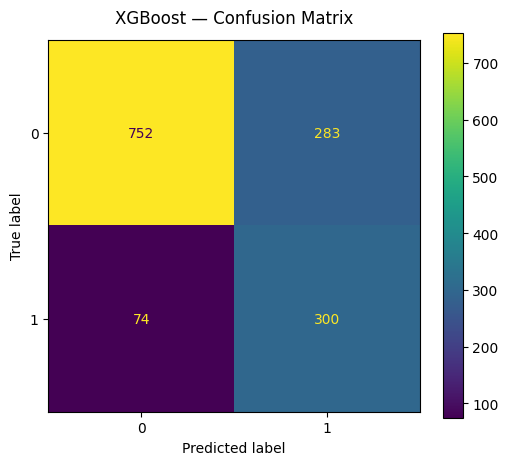

In [84]:
plot_confusion_matrix(
	best_xgb_pipe,
	y_test_encoded,
	y_pred_xgb,
	'XGBoost — Confusion Matrix',
)

### ROC Curve Analysis

The ROC curve illustrates the XGBoost classifier's discriminative capability across multiple classification thresholds.

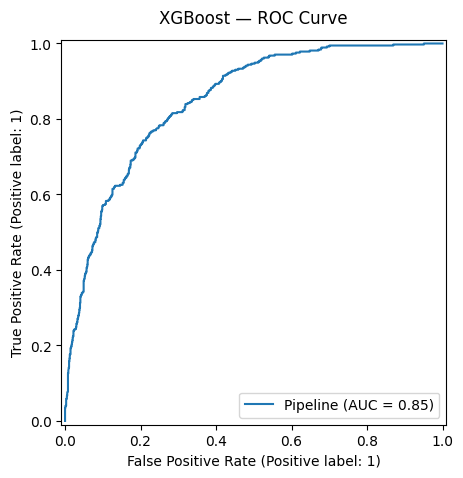

In [85]:
plot_roc_curve(
	best_xgb_pipe,
	X_test,
	y_test_encoded,
	'XGBoost — ROC Curve',
)

## Model Export and Saved Artifacts

The optimized XGBoost pipeline and training metadata are exported for future inference and deployment workflows.

The following artifacts are persisted:

- Best trained XGBoost pipeline
- Best hyperparameter configuration
- Best cross-validation ROC-AUC score
- Training time

In [86]:
base_xgb_path = 'models/xgboost'

xgb_artifacts = {
	'model_name': 'xgboost',
	'best_params': xgb_study.best_params,
	'best_cv_score': xgb_study.best_value,
	'test_metrics': xgb_metrics,
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
	'predict_time': xgb_predict_time,
}

save_artifacts(base_xgb_path, xgb_artifacts, best_xgb_pipe)

# Model Comparison

This section loads the `*_artifacts.joblib` files from each model directory, aggregates the core metrics, and produces a clean side-by-side comparison.

The metrics reported are:

| Metric | Why it matters for churn prediction |
|---|---|
| **ROC AUC** | Overall discriminative power across all thresholds |
| **Precision** | Of all customers flagged as churned, how many actually did |
| **Recall** | Of all customers who churned, how many were correctly caught |
| **F1-Score** | Harmonic mean of Precision and Recall |
| **Training Time** | Wall-clock time to fit the best pipeline on the training set |

The best-performing model will be selected for deployment in the Streamlit dashboard.

In [87]:
logreg_artifacts = load(
	'models/logistic_regression/logistic_regression_artifacts.joblib',
)

dt_artifacts = load(
	'models/decision_tree/decision_tree_artifacts.joblib',
)

rf_artifacts = load(
	'models/random_forest/random_forest_artifacts.joblib',
)

xgb_artifacts = load(
	'models/xgboost/xgboost_artifacts.joblib',
)

In [88]:
all_artifacts = [
	logreg_artifacts,
	dt_artifacts,
	rf_artifacts,
	xgb_artifacts,
]

In [89]:
comparison_rows = []

for artifact in all_artifacts:
	metrics = artifact['test_metrics']
	cv_strategy = artifact['cv_strategy']

	row = {
		'Model': artifact['model_name'].replace('_', ' ').title(),
		'ROC AUC': round(metrics.get('test_roc_auc', 0), 4),
		'PR AUC': round(metrics.get('test_pr_auc', 0), 4),
		'Accuracy': round(metrics.get('test_accuracy', 0), 4),
		'Precision': round(metrics.get('test_precision', 0), 4),
		'Recall': round(metrics.get('test_recall', 0), 4),
		'F1-Score': round(metrics.get('test_f1', 0), 4),
		'Predict Time (ms)': artifact.get('predict_time', None),
	}

	comparison_rows.append(row)

In [90]:
comparison_df = pd.DataFrame(comparison_rows)

In [91]:
comparison_df = comparison_df.sort_values(
	by='ROC AUC',
	ascending=False,
).reset_index(drop=True)

In [92]:
display(comparison_df)

,Model,ROC AUC,PR AUC,Accuracy,Precision,Recall,F1-Score,Predict Time (ms)
0,Xgboost,0.8477,0.6613,0.7466,0.5146,0.8021,0.6270,0.010730
1,Random Forest,0.8436,0.6534,0.7594,0.5314,0.7914,0.6359,0.023728
2,Logistic Regression,0.8395,0.6310,0.7402,0.5070,0.7781,0.6139,0.006877
3,Decision Tree,0.8349,0.6279,0.7615,0.5347,0.7834,0.6356,0.006168


In [93]:
report_base_path = 'reports'

os.makedirs(report_base_path, exist_ok=True)

In [94]:
comparison_df.to_csv(
	f'{report_base_path}/model_comparison.csv',
	index=False,
)